# Deng--Ginting Example 4 style transport on 5x5 tanh-block permeability, Q1 CG

This notebook is a no-fracture source--sink benchmark on \(\Omega=(0,1)^2\), inspired by Deng--Ginting Example 4.  It keeps the 5x5 tanh-blended block permeability/grid from the MRST export, and solves the boundary-pressure problem by

\[
-\nabla\cdot(\kappa\nabla p)=q_I\chi_{K_I}/|K_I|-q_P\chi_{K_P}/|K_P|,
\qquad p=0\quad\text{on }\partial\Omega.
\]

The source points are the Deng locations scaled from \((0,5)\times(0,1)\) to \((0,1)^2\): \(x_I=(0.2,0.4)\), \(x_P=(0.8,0.5)\).  The point sources are regularized as cell-integrated sources on the matching primal/MRST cells.  Transport uses clean boundary inflow \(S=0\), source concentration \(S_I=1\), and an explicit upwind Buckley--Leverett update on the Deng nodal dual control volumes \(C_z\).

Flux choices:

- `CG`: raw Q1 CG flux, averaged on transport-cell interfaces.
- `NLR`: Deng/Ginting local Q1 reconstruction on nodal dual control volumes.
- `CVFEM`: vertex-centred control-volume finite-element pressure solve on the same nodal dual mesh.
- `PINN`: optional pressure-gradient network reconstruction with harmonic face permeability.
- `MRST`: fine-pressure/dual-transport reference from `case3_mrst_export_blocks5_finep_dualT.mat`.


In [1]:
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from scipy.io import loadmat
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

try:
    import torch
    import torch.nn as nn
    from tqdm.auto import tqdm
    TORCH_AVAILABLE = True
except ModuleNotFoundError:
    torch = None
    nn = None
    TORCH_AVAILABLE = False

    def tqdm(iterable, **kwargs):
        return iterable

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

np.random.seed(1234)
if TORCH_AVAILABLE:
    torch.manual_seed(1234)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = "numpy"

# 5x5 tanh-block MRST export.  This file provides kappa_primal on the
# 64x64 primal grid and the conservative MRST dual-mesh saturation reference.
DATA_CANDIDATES = [
    pathlib.Path("case3_ecmor/case3_mrst_export_blocks5_finep_dualT.mat"),
]
DATA_FILE = None
for candidate in DATA_CANDIDATES:
    if candidate.exists():
        DATA_FILE = candidate
        break
if DATA_FILE is None:
    for candidate in DATA_CANDIDATES:
        matches = sorted(pathlib.Path.cwd().glob(f"**/{candidate.as_posix()}"))
        if matches:
            DATA_FILE = matches[0]
            break
if DATA_FILE is None or not DATA_FILE.exists():
    raise FileNotFoundError("Could not find case3_mrst_export_blocks5_finep_dualT.mat.")

mrst = loadmat(DATA_FILE, squeeze_me=True, struct_as_record=False)

FINE_MRST_CANDIDATES = [
    pathlib.Path("case3_ecmor/case3_mrst_export_blocks5_finep_dualT.mat"),
]
FINE_MRST_FILE = DATA_FILE
mrst_fine = mrst
MRST_FINE_AVAILABLE = bool(mrst_fine)


def _arr(key, dtype=float):
    if key not in mrst:
        raise KeyError(f"Missing MRST field {key!r}")
    return np.asarray(mrst[key], dtype=dtype)


def _meta_float(key, default=np.nan):
    if key not in mrst:
        return float(default)
    values = np.asarray(mrst[key]).reshape(-1)
    return float(values[0]) if values.size else float(default)


def _meta_str(key, default=""):
    return str(mrst.get(key, default))


nx = ny = 64
physdim = np.array([1.0, 1.0], dtype=float)
phi_matrix = 1.0
PV_matrix = phi_matrix * float(np.prod(physdim))
CFL = _meta_float("meta_CFL", 0.45)
FPRIME_MAX = _meta_float("meta_FPRIME_MAX", 2.0)
CASE_NAME = "5x5 tanh blocks"
BLEND_DELTA = _meta_float("blend_delta", 0.05)
BLOCK_KIJ = np.asarray(mrst.get("block_Kij", np.empty((0, 0))), dtype=float)

xmin, ymin = 0.0, 0.0
xmax, ymax = float(physdim[0]), float(physdim[1])
hx = physdim[0] / nx
hy = physdim[1] / ny
h_est = min(hx, hy)
ncell = nx * ny
cell_area = np.full(ncell, float(np.prod(physdim)) / ncell, dtype=float)
cell_pv = phi_matrix * cell_area

# Primal cell centers, x-fast numbering: cid = iy*nx + ix.
x_centers = xmin + (np.arange(nx) + 0.5) * hx
y_centers = ymin + (np.arange(ny) + 0.5) * hy
Xc, Yc = np.meshgrid(x_centers, y_centers, indexing="xy")
xc_matrix = np.column_stack([Xc.ravel(), Yc.ravel()])

if "kappa_primal" not in mrst:
    raise KeyError("The blocks5 export must contain kappa_primal.")
_kappa_primal = np.asarray(mrst["kappa_primal"], dtype=float)
if _kappa_primal.shape != (nx, ny):
    _kappa_primal = _kappa_primal.reshape((nx, ny), order="F")
# MATLAB stores kappa_primal(i_x, i_y); Python cell ids are x-fast inside each y row.
kappa_cell_dg0 = _kappa_primal.T.reshape(-1)
KAPPA_CONTRAST = float(np.nanmax(kappa_cell_dg0) / np.nanmin(kappa_cell_dg0))


def build_structured_primal_faces(nx, ny, physdim):
    hx_loc = float(physdim[0]) / nx
    hy_loc = float(physdim[1]) / ny
    neighbors = []
    centroids = []
    normals = []
    lengths = []
    p1s = []
    p2s = []

    def cid(ix, iy):
        return iy * nx + ix + 1  # 1-based, MRST style

    # Vertical faces. Internal normals point left -> right. Boundary normals point outward.
    for iy in range(ny):
        y0 = iy * hy_loc
        y1 = (iy + 1) * hy_loc
        for ix in range(nx + 1):
            x = ix * hx_loc
            if ix == 0:
                nb = [cid(0, iy), 0]
                n = [-1.0, 0.0]
            elif ix == nx:
                nb = [cid(nx - 1, iy), 0]
                n = [1.0, 0.0]
            else:
                nb = [cid(ix - 1, iy), cid(ix, iy)]
                n = [1.0, 0.0]
            neighbors.append(nb)
            centroids.append([x, 0.5 * (y0 + y1)])
            normals.append(n)
            lengths.append(hy_loc)
            p1s.append([x, y0])
            p2s.append([x, y1])

    # Horizontal faces. Internal normals point bottom -> top. Boundary normals point outward.
    for iy in range(ny + 1):
        y = iy * hy_loc
        for ix in range(nx):
            x0 = ix * hx_loc
            x1 = (ix + 1) * hx_loc
            if iy == 0:
                nb = [cid(ix, 0), 0]
                n = [0.0, -1.0]
            elif iy == ny:
                nb = [cid(ix, ny - 1), 0]
                n = [0.0, 1.0]
            else:
                nb = [cid(ix, iy - 1), cid(ix, iy)]
                n = [0.0, 1.0]
            neighbors.append(nb)
            centroids.append([0.5 * (x0 + x1), y])
            normals.append(n)
            lengths.append(hx_loc)
            p1s.append([x0, y])
            p2s.append([x1, y])

    return (
        np.asarray(neighbors, dtype=np.int64),
        np.asarray(centroids, dtype=float),
        np.asarray(normals, dtype=float),
        np.asarray(lengths, dtype=float),
        np.asarray(p1s, dtype=float),
        np.asarray(p2s, dtype=float),
    )

face_neighbors, face_centroid, face_normal, face_len, face_p1, face_p2 = build_structured_primal_faces(nx, ny, physdim)
face_is_boundary = np.any(face_neighbors == 0, axis=1)
face_flux_mrst_export = None
p_matrix_mrst_export = None
kappa_cell_mrst = kappa_cell_dg0.copy()
MRST_REFERENCE_AVAILABLE = False

# Deng Example 4, x-coordinate scaled from [0,5] to [0,1].  The delta sources
# are regularized as cell-integrated sources on the selected grid cells.
SOURCE_POINTS_REQUESTED = np.array([[0.2, 0.4], [0.8, 0.5]], dtype=float)
SOURCE_RATES = np.array([1.0, -5.0], dtype=float)  # + spill/injector, - leakage/producer
SOURCE_SATURATION = 1.0
BOUNDARY_INFLOW_S = 0.0  # clean external reservoir on any pressure-boundary inflow
TRANSPORT_T_VALUES = np.array([0.05, 0.25, 0.8], dtype=float)
TRANSPORT_CASE_KEY = "T0.05"
TRANSPORT_CLIP = True
TRANSPORT_USE_FIXED_DT = False
TRANSPORT_DT = 1.0e-4  # Optional paper-style fixed dt; CFL mode is safer here.


def rect_cell_ids_from_points(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xp = np.clip(pts[:, 0], xmin, np.nextafter(xmax, xmin))
    yp = np.clip(pts[:, 1], ymin, np.nextafter(ymax, ymin))
    ix = np.floor((xp - xmin) / hx).astype(int)
    iy = np.floor((yp - ymin) / hy).astype(int)
    ix = np.clip(ix, 0, nx - 1)
    iy = np.clip(iy, 0, ny - 1)
    return iy * nx + ix


def kappa_numpy(points):
    return kappa_cell_dg0[rect_cell_ids_from_points(points)]

source_cell_ids = rect_cell_ids_from_points(SOURCE_POINTS_REQUESTED)
source_rate_cell = np.zeros(ncell, dtype=float)
for cid, rate in zip(source_cell_ids, SOURCE_RATES):
    source_rate_cell[int(cid)] += float(rate)
source_density_cell = source_rate_cell / cell_area
source_rate_total = float(np.sum(source_rate_cell))
source_rate_positive = float(np.sum(np.maximum(source_rate_cell, 0.0)))
source_rate_negative = float(np.sum(np.minimum(source_rate_cell, 0.0)))
source_points_effective = xc_matrix[source_cell_ids]


def f_numpy(points):
    return source_density_cell[rect_cell_ids_from_points(points)]


def polygon_signed_area(poly):
    poly = np.asarray(poly, dtype=float)
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0.0:
        poly = poly[::-1]
    return poly


def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def outward_edge_normal(a, b, centroid):
    t = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (np.asarray(a, dtype=float) + np.asarray(b, dtype=float))
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1.0e-30)


def residual_stats(vals, ids=None):
    arr = np.asarray(vals, dtype=float).reshape(-1)
    if ids is not None:
        arr = arr[np.asarray(ids, dtype=np.int64)]
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return "n=0"
    return (
        f"n={arr.size:d} mean|R|={np.mean(np.abs(arr)):.6e} "
        f"median|R|={np.median(np.abs(arr)):.6e} "
        f"rmse={np.sqrt(np.mean(arr**2)):.6e} "
        f"max|R|={np.max(np.abs(arr)):.6e} sum(R)={np.sum(arr):+.6e}"
    )

print(f"Loaded {DATA_FILE}")
print(f"{CASE_NAME} grid: {nx} x {ny}, cells={ncell}, primal faces={len(face_neighbors)}")
print(f"kappa range=[{np.nanmin(kappa_cell_dg0):.6g}, {np.nanmax(kappa_cell_dg0):.6g}], contrast={KAPPA_CONTRAST:.3f}, delta={BLEND_DELTA:.3g}, PV={PV_matrix:.8e}")
print("Deng-style source/sink regularized on grid cells:")
for req, eff, cid, rate in zip(SOURCE_POINTS_REQUESTED, source_points_effective, source_cell_ids, SOURCE_RATES):
    ix, iy = int(cid % nx), int(cid // nx)
    print(f"  requested={req}, effective cell center={eff}, cell={int(cid)}, primal=({ix+1},{iy+1}), rate={rate:+.6e}")
print(f"  total source integral={source_rate_total:+.6e}, positive injection={source_rate_positive:.6e}, negative sink={source_rate_negative:.6e}")
print(f"MRST primal 64x64 reference available: {MRST_REFERENCE_AVAILABLE}")
print(f"MRST fine-pressure / dual-transport reference available: {MRST_FINE_AVAILABLE}" + (f" ({FINE_MRST_FILE})" if MRST_FINE_AVAILABLE else ""))
if MRST_FINE_AVAILABLE:
    print(f"  MRST dual conservation_residual={_meta_float('conservation_residual', np.nan):.3e}")


Loaded case3_ecmor/case3_mrst_export_blocks5_finep_dualT.mat
5x5 tanh blocks grid: 64 x 64, cells=4096, primal faces=8320
kappa range=[0.398203, 38.531], contrast=96.762, delta=0.05, PV=1.00000000e+00
Deng-style source/sink regularized on grid cells:
  requested=[0.2 0.4], effective cell center=[0.1953125 0.3984375], cell=1612, primal=(13,26), rate=+1.000000e+00
  requested=[0.8 0.5], effective cell center=[0.8046875 0.5078125], cell=2099, primal=(52,33), rate=-5.000000e+00
  total source integral=-4.000000e+00, positive injection=1.000000e+00, negative sink=-5.000000e+00
MRST primal 64x64 reference available: False
MRST fine-pressure / dual-transport reference available: True (case3_ecmor/case3_mrst_export_blocks5_finep_dualT.mat)
  MRST dual conservation_residual=8.715e-15


/home/muchamad/PhD/fenicsx/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Q1 CG pressure solve
  p range: [-3.472248e-01, +4.637089e-02]
  source integral sum_K int_K f dx = -4.00000000e+00
  source density range: [-2.048e+04, +4.096e+03]


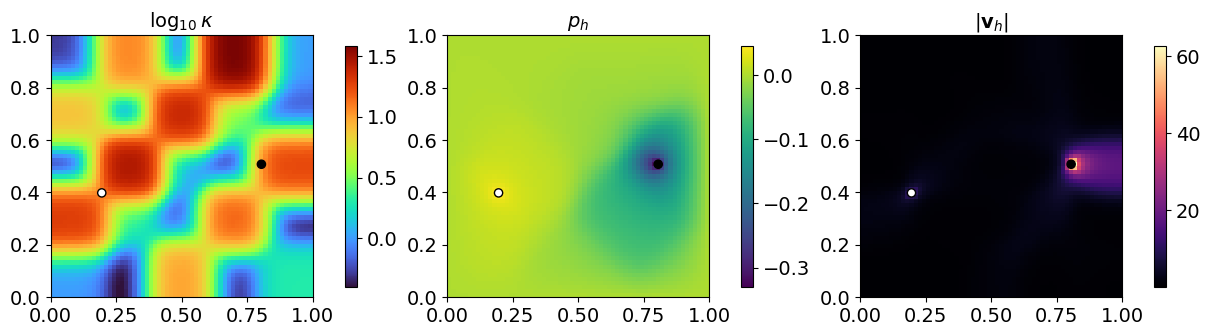

In [2]:
# Q1 CG pressure solve with homogeneous Dirichlet boundary and cell-regularized sources.

def q1_phi(xi_eta):
    xi = np.asarray(xi_eta)[..., 0]
    eta = np.asarray(xi_eta)[..., 1]
    return np.stack([
        (1.0 - xi) * (1.0 - eta),
        xi * (1.0 - eta),
        (1.0 - xi) * eta,
        xi * eta,
    ], axis=-1)


def q1_grad_ref(xi_eta):
    xi = np.asarray(xi_eta)[..., 0]
    eta = np.asarray(xi_eta)[..., 1]
    dxi = np.stack([-(1.0 - eta), (1.0 - eta), -eta, eta], axis=-1)
    deta = np.stack([-(1.0 - xi), -xi, (1.0 - xi), xi], axis=-1)
    return np.stack([dxi, deta], axis=-1)


def q1_grad_phys(xi_eta, hx_val, hy_val):
    g = q1_grad_ref(xi_eta).astype(float)
    g[..., 0] /= hx_val
    g[..., 1] /= hy_val
    return g


def _nid(i, j):
    return j * (nx + 1) + i

x_nodes = np.linspace(xmin, xmax, nx + 1)
y_nodes = np.linspace(ymin, ymax, ny + 1)
Xn, Yn = np.meshgrid(x_nodes, y_nodes, indexing="xy")
fem_nodes = np.column_stack([Xn.ravel(), Yn.ravel()])
n_nodes = fem_nodes.shape[0]

quad_nodes = []
quad_polys = []
for j in range(ny):
    for i in range(nx):
        ll = _nid(i, j)
        lr = _nid(i + 1, j)
        ul = _nid(i, j + 1)
        ur = _nid(i + 1, j + 1)
        quad_nodes.append([ll, lr, ul, ur])
        x0, x1 = x_nodes[i], x_nodes[i + 1]
        y0, y1 = y_nodes[j], y_nodes[j + 1]
        quad_polys.append(np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=float))
quad_nodes = np.asarray(quad_nodes, dtype=np.int64)
quad_polys = np.asarray(quad_polys, dtype=float)
quad_centroids = xc_matrix.copy()

# 2x2 Gauss quadrature on [0,1]^2.
_g1 = 0.5 - 0.5 / np.sqrt(3.0)
_g2 = 0.5 + 0.5 / np.sqrt(3.0)
_Q2 = np.array([[_g1, _g1], [_g2, _g1], [_g1, _g2], [_g2, _g2]], dtype=float)
_W2 = np.full(4, 0.25, dtype=float)

A = lil_matrix((n_nodes, n_nodes), dtype=float)
b = np.zeros(n_nodes, dtype=float)
cell_area_scalar = hx * hy
for cid, nodes in enumerate(quad_nodes):
    k_elem = float(kappa_cell_dg0[cid])
    grads_q = q1_grad_phys(_Q2, hx, hy)
    Ke = cell_area_scalar * np.einsum("q,qia,qja->ij", _W2, k_elem * grads_q, grads_q)
    for a in range(4):
        ia = int(nodes[a])
        for c in range(4):
            A[ia, int(nodes[c])] += Ke[a, c]
    if source_rate_cell[cid] != 0.0:
        # Uniform cell regularization of the delta: integral f phi_i = Q_K/4.
        b[nodes] += 0.25 * source_rate_cell[cid]

boundary_nodes = (
    np.isclose(fem_nodes[:, 0], xmin, atol=1.0e-14)
    | np.isclose(fem_nodes[:, 0], xmax, atol=1.0e-14)
    | np.isclose(fem_nodes[:, 1], ymin, atol=1.0e-14)
    | np.isclose(fem_nodes[:, 1], ymax, atol=1.0e-14)
)
p_dirichlet = np.zeros(n_nodes, dtype=float)

A = A.tolil()
b -= A[:, boundary_nodes].dot(p_dirichlet[boundary_nodes])
for idx in np.flatnonzero(boundary_nodes):
    A.rows[idx] = [int(idx)]
    A.data[idx] = [1.0]
for idx in np.flatnonzero(boundary_nodes):
    A[:, idx] = 0.0
    A[idx, idx] = 1.0
    b[idx] = p_dirichlet[idx]

p_nodes = np.asarray(spsolve(A.tocsr(), b), dtype=float)


def locate_rect_cells(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xp = np.clip(pts[:, 0], xmin, np.nextafter(xmax, xmin))
    yp = np.clip(pts[:, 1], ymin, np.nextafter(ymax, ymin))
    ix = np.floor((xp - xmin) / hx).astype(int)
    iy = np.floor((yp - ymin) / hy).astype(int)
    ix = np.clip(ix, 0, nx - 1)
    iy = np.clip(iy, 0, ny - 1)
    xi = (pts[:, 0] - (xmin + ix * hx)) / hx
    eta = (pts[:, 1] - (ymin + iy * hy)) / hy
    xi = np.clip(xi, 0.0, 1.0)
    eta = np.clip(eta, 0.0, 1.0)
    cid = iy * nx + ix
    return cid.astype(np.int64), xi, eta


def p_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, xi, eta = locate_rect_cells(pts)
    phi = q1_phi(np.column_stack([xi, eta]))
    return np.einsum("ni,ni->n", phi, p_nodes[quad_nodes[cid]])


def grad_p_cg_on_rect_cell_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    if len(cids) != len(pts):
        raise ValueError("cell_ids must have the same length as points")
    ix = np.clip(cids % nx, 0, nx - 1)
    iy = np.clip(cids // nx, 0, ny - 1)
    xi = (pts[:, 0] - (xmin + ix * hx)) / hx
    eta = (pts[:, 1] - (ymin + iy * hy)) / hy
    xi = np.clip(xi, 0.0, 1.0)
    eta = np.clip(eta, 0.0, 1.0)
    grads = q1_grad_phys(np.column_stack([xi, eta]), hx, hy)
    return np.einsum("nij,nj->ni", grads.transpose(0, 2, 1), p_nodes[quad_nodes[cids]])


def grad_p_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, _, _ = locate_rect_cells(pts)
    return grad_p_cg_on_rect_cell_numpy(pts, cid)


def q_cg_on_rect_cell_numpy(points, cell_ids):
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    return -kappa_cell_dg0[cids, None] * grad_p_cg_on_rect_cell_numpy(points, cids)


def q_cg_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, _, _ = locate_rect_cells(pts)
    return q_cg_on_rect_cell_numpy(pts, cid)

p_matrix_cg = p_cg_numpy(xc_matrix)
grad_cell_cg = grad_p_cg_numpy(xc_matrix)
q_cell_cg = -kappa_cell_dg0[:, None] * grad_cell_cg

print("Q1 CG pressure solve")
print(f"  p range: [{p_nodes.min():+.6e}, {p_nodes.max():+.6e}]")
print(f"  source integral sum_K int_K f dx = {source_rate_total:+.8e}")
print(f"  source density range: [{source_density_cell.min():+.3e}, {source_density_cell.max():+.3e}]")
if MRST_REFERENCE_AVAILABLE:
    p_matrix_diff_cg_mrst = p_matrix_cg - p_matrix_mrst_export
    print(f"  matched MRST pressure mean|e|={np.mean(np.abs(p_matrix_diff_cg_mrst)):.3e}, max|e|={np.max(np.abs(p_matrix_diff_cg_mrst)):.3e}")


def cell_field_to_grid(field):
    field = np.asarray(field, dtype=float).reshape(-1)
    ix = np.rint((xc_matrix[:, 0] - 0.5 * hx) / hx).astype(int)
    iy = np.rint((xc_matrix[:, 1] - 0.5 * hy) / hy).astype(int)
    grid = np.full((ny, nx), np.nan, dtype=float)
    grid[iy, ix] = field
    return grid

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)
with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), constrained_layout=True)
    pcm0 = axes[0].pcolormesh(x_edges, y_edges, cell_field_to_grid(np.log10(kappa_cell_dg0)), cmap="turbo", shading="flat")
    axes[0].set_title(r"$\log_{10}\kappa$")
    pcm1 = axes[1].pcolormesh(x_edges, y_edges, cell_field_to_grid(p_matrix_cg), cmap="viridis", shading="flat")
    axes[1].set_title(r"$p_h$")
    pcm2 = axes[2].pcolormesh(x_edges, y_edges, cell_field_to_grid(np.linalg.norm(q_cell_cg, axis=1)), cmap="magma", shading="flat")
    axes[2].set_title(r"$|\mathbf{v}_h|$")
    for ax in axes:
        ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(False)
    fig.colorbar(pcm0, ax=axes[0], fraction=0.046, pad=0.04)
    fig.colorbar(pcm1, ax=axes[1], fraction=0.046, pad=0.04)
    fig.colorbar(pcm2, ax=axes[2], fraction=0.046, pad=0.04)
    plt.show()


Deng Q1 rectangular local solves: 100%|██████████| 4096/4096 [00:19<00:00, 215.43it/s]


Deng/NLR reconstruction time: 19.040 s
Element/control-volume conservation residuals
  R_tau CG       : n=4096 mean|R|=1.464844e-03 median|R|=5.421011e-20 rmse=7.967218e-02 max|R|=5.000000e+00 sum(R)=+4.000000e+00
  R_tau NLR      : n=4096 mean|R|=1.464844e-03 median|R|=5.421011e-20 rmse=7.967218e-02 max|R|=5.000000e+00 sum(R)=+4.000000e+00
  R_xi CG int    : n=3969 mean|R|=2.098682e-04 median|R|=2.337437e-06 rmse=2.350225e-03 max|R|=4.566685e-02 sum(R)=-7.403918e-05
  R_xi NLR int   : n=3969 mean|R|=9.989372e-17 median|R|=1.908196e-17 rmse=2.861640e-16 max|R|=4.232725e-15 sum(R)=+2.460503e-14
  R_xi CG source : n=8 mean|R|=2.492876e-02 median|R|=2.335894e-02 rmse=2.997498e-02 max|R|=4.566685e-02 sum(R)=-1.310250e-01
  R_xi NLR source: n=8 mean|R|=6.800116e-16 median|R|=3.885781e-16 rmse=8.790239e-16 max|R|=1.776357e-15 sum(R)=-1.221245e-15


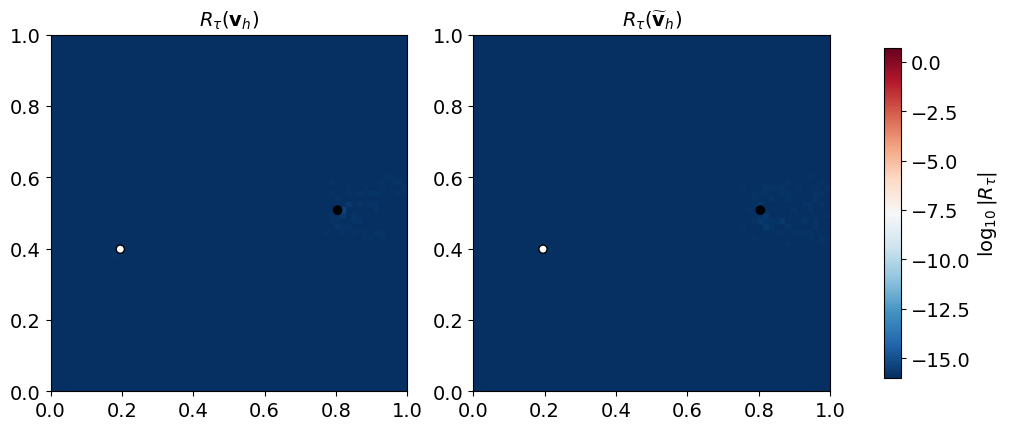

In [3]:
# Deng/Ginting Q1 local reconstruction on rectangular nodal dual control volumes.
RUN_DENG_RECONSTRUCTION = True
_G3 = np.array([0.5 - 0.5 * np.sqrt(3.0 / 5.0), 0.5, 0.5 + 0.5 * np.sqrt(3.0 / 5.0)], dtype=float)
_W3 = np.array([5.0 / 18.0, 4.0 / 9.0, 5.0 / 18.0], dtype=float)

edge_defs = [(0, 1), (1, 3), (3, 2), (2, 0)]
next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}

rect_cells = []
edge_to_cells = {}
vtc = [[] for _ in range(n_nodes)]
for cid, nodes in enumerate(quad_nodes):
    poly_ccw = quad_polys[cid]
    corners = np.array([poly_ccw[0], poly_ccw[1], poly_ccw[3], poly_ccw[2]], dtype=float)  # ll, lr, ul, ur
    cell = {
        "xy": corners,
        "poly": poly_ccw,
        "vids": nodes.copy(),
        "hx": hx,
        "hy": hy,
        "centroid": xc_matrix[cid].copy(),
        "uvals": p_nodes[nodes].copy(),
        "cell_id": cid,
        "kappa": float(kappa_cell_dg0[cid]),
    }
    rect_cells.append(cell)
    for vid in nodes:
        vtc[int(vid)].append(cid)
    for e, (a, b_) in enumerate(edge_defs):
        key = tuple(sorted((int(nodes[a]), int(nodes[b_]))))
        edge_to_cells.setdefault(key, []).append((cid, e))
rect = {"cells": rect_cells, "edge_to_cells": edge_to_cells, "vtc": vtc, "edge_defs": edge_defs, "num_cells": ncell, "num_vertices": n_nodes, "vertices_xy": fem_nodes}


def ref_from_phys(cell, x):
    x0, y0 = cell["xy"][0]
    return np.array([(x[0] - x0) / cell["hx"], (x[1] - y0) / cell["hy"]], dtype=float)


def grad_from_coeffs(cell, coeffs, x):
    xi = ref_from_phys(cell, x)
    grads = q1_grad_phys(xi[None, :], cell["hx"], cell["hy"])[0]
    return grads.T @ coeffs


def normal_from_C_to_ti(centroid, midpoint, vi):
    tangent = np.asarray(midpoint, dtype=float) - np.asarray(centroid, dtype=float)
    n1 = np.array([tangent[1], -tangent[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (np.asarray(centroid, dtype=float) + np.asarray(midpoint, dtype=float))
    chosen = n1 if np.dot(n1, np.asarray(vi, dtype=float) - seg_mid) < 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1.0e-30)


def integrate_segment_basis_flux(cell, a, b_, n_out):
    seg_len = edge_length(a, b_)
    out = np.zeros(4, dtype=float)
    for t, w in zip(_G3, _W3):
        x = a + t * (b_ - a)
        xi = ref_from_phys(cell, x)
        grads = q1_grad_phys(xi[None, :], cell["hx"], cell["hy"])[0]
        out += w * (-(cell["kappa"]) * (grads @ n_out)) * seg_len
    return out


def averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out):
    cell = rect["cells"][ci]
    val = cell["kappa"] * grad_from_coeffs(cell, cell["uvals"], x)
    adj = [c for c, _ in rect["edge_to_cells"].get(edge_key, [])]
    if len(adj) == 2:
        nb = adj[0] if adj[1] == ci else adj[1]
        cell_nb = rect["cells"][nb]
        val_nb = cell_nb["kappa"] * grad_from_coeffs(cell_nb, cell_nb["uvals"], x)
        val = 0.5 * (val + val_nb)
    return float(np.dot(val, n_out))


def segment_flux(cell, coeffs, a, b_, n_out):
    seg_len = edge_length(a, b_)
    flux = 0.0
    for t, w in zip(_G3, _W3):
        x = a + t * (b_ - a)
        grad = grad_from_coeffs(cell, coeffs, x)
        flux += w * np.dot(-(cell["kappa"]) * grad, n_out) * seg_len
    return float(flux)


def deng_postprocess_rect_source(rect):
    local_fluxes = {}
    coef_glob = {i: [] for i in range(rect["num_vertices"])}
    qp = _Q2
    qw = _W2
    dirichlet_tol = 1.0e-12

    for ci in tqdm(range(rect["num_cells"]), desc="Deng Q1 rectangular local solves"):
        cell = rect["cells"][ci]
        xy = cell["xy"]
        area = cell["hx"] * cell["hy"]
        centroid = cell["centroid"]
        uvals = cell["uvals"]
        k_elem = cell["kappa"]

        B = np.zeros((4, 4), dtype=float)
        source_t = np.full(4, 0.25 * source_rate_cell[ci], dtype=float)
        source_phi = np.full(4, 0.25 * source_rate_cell[ci], dtype=float)
        a_term = np.zeros(4, dtype=float)
        e_I = np.zeros(4, dtype=float)
        e_phi = np.zeros(4, dtype=float)

        grads_q = q1_grad_phys(qp, cell["hx"], cell["hy"])
        grad_u_q = np.einsum("qjd,j->qd", grads_q, uvals)
        a_term += area * np.einsum("q,qjd,qd->j", qw, k_elem * grads_q, grad_u_q)

        for gi in range(4):
            vi = xy[gi]
            vn = xy[next_ccw[gi]]
            vp = xy[prev_ccw[gi]]
            mid_next = 0.5 * (vi + vn)
            mid_prev = 0.5 * (vi + vp)
            for midp in (mid_next, mid_prev):
                n_seg = normal_from_C_to_ti(centroid, midp, vi)
                B[gi, :] += integrate_segment_basis_flux(cell, centroid, midp, n_seg)

        for a_id, b_id in rect["edge_defs"]:
            a = xy[a_id]
            bpt = xy[b_id]
            n_out = outward_edge_normal(a, bpt, centroid)
            edge_key_local = tuple(sorted((int(cell["vids"][a_id]), int(cell["vids"][b_id]))))
            seg_len = edge_length(a, bpt)
            for t, w in zip(_G3, _W3):
                x = a + t * (bpt - a)
                xi = ref_from_phys(cell, x)
                phi_edge = q1_phi(xi[None, :])[0]
                avg = averaged_kgrad_dot_n(rect, ci, edge_key_local, x, n_out)
                e_phi += w * avg * phi_edge * seg_len
            for gi, other in ((a_id, b_id), (b_id, a_id)):
                half_end = 0.5 * (xy[gi] + xy[other])
                half_len = edge_length(xy[gi], half_end)
                for t, w in zip(_G3, _W3):
                    x = xy[gi] + t * (half_end - xy[gi])
                    avg = averaged_kgrad_dot_n(rect, ci, edge_key_local, x, n_out)
                    e_I[gi] += w * avg * half_len

        rhs = source_t - source_phi + a_term + e_I - e_phi
        fixed = {}
        for li, xyi in enumerate(xy):
            if (
                abs(xyi[0] - xmin) < dirichlet_tol
                or abs(xyi[0] - xmax) < dirichlet_tol
                or abs(xyi[1] - ymin) < dirichlet_tol
                or abs(xyi[1] - ymax) < dirichlet_tol
            ):
                fixed[li] = 0.0

        A_loc = B.copy()
        bvec = rhs.copy()
        for lid, val in fixed.items():
            bvec -= A_loc[:, lid] * val
        free = [i for i in range(4) if i not in fixed]
        coeffs = np.zeros(4, dtype=float)
        for lid, val in fixed.items():
            coeffs[lid] = val
        if free:
            coeffs[np.asarray(free)] = np.linalg.lstsq(A_loc[:, free], bvec, rcond=None)[0]

        local_fluxes[ci] = {"coeffs": coeffs, "source_t": source_t.copy(), "source_phi": source_phi.copy(), "rhs": rhs.copy()}
        for li, vid in enumerate(cell["vids"]):
            coef_glob[int(vid)].append(coeffs[li])

    p_rec = np.zeros(rect["num_vertices"], dtype=float)
    for vid, vals in coef_glob.items():
        p_rec[vid] = float(np.mean(vals)) if vals else np.nan
    return local_fluxes, coef_glob, p_rec


def compute_R_tau_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_cells"], dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        xy = cell["xy"]
        centroid = cell["centroid"]
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
        flux = 0.0
        for a_id, b_id in rect["edge_defs"]:
            a = xy[a_id]
            bpt = xy[b_id]
            n_out = outward_edge_normal(a, bpt, centroid)
            flux += segment_flux(cell, coeffs, a, bpt, n_out)
        R[ci] = flux - source_rate_cell[ci]
    return R


def compute_R_xi_rect(rect, local_fluxes, use_rec=True):
    R = np.zeros(rect["num_vertices"], dtype=float)
    for vid in range(rect["num_vertices"]):
        flux_sum = 0.0
        source_sum = 0.0
        for ci in rect["vtc"][vid]:
            cell = rect["cells"][ci]
            loc = np.where(cell["vids"] == vid)[0]
            if len(loc) == 0:
                continue
            gi = int(loc[0])
            xy = cell["xy"]
            vi = xy[gi]
            mid_next = 0.5 * (vi + xy[next_ccw[gi]])
            mid_prev = 0.5 * (vi + xy[prev_ccw[gi]])
            centroid = cell["centroid"]
            coeffs = local_fluxes[ci]["coeffs"] if use_rec else cell["uvals"]
            for midp in (mid_next, mid_prev):
                n_seg = normal_from_C_to_ti(centroid, midp, vi)
                flux_sum += segment_flux(cell, coeffs, centroid, midp, n_seg)
            source_sum += local_fluxes[ci]["source_t"][gi]
        R[vid] = flux_sum - source_sum
    return R


def boundary_vertex_mask_rect(rect):
    xy = rect["vertices_xy"]
    tol = 1.0e-12
    return (
        np.isclose(xy[:, 0], xmin, atol=tol)
        | np.isclose(xy[:, 0], xmax, atol=tol)
        | np.isclose(xy[:, 1], ymin, atol=tol)
        | np.isclose(xy[:, 1], ymax, atol=tol)
    )

if RUN_DENG_RECONSTRUCTION:
    t0 = time.perf_counter()
    local_fluxes, coef_glob, p_nlr_nodes = deng_postprocess_rect_source(rect)
    deng_reconstruction_time = time.perf_counter() - t0
else:
    local_fluxes = {ci: {"coeffs": rect["cells"][ci]["uvals"].copy(), "source_t": np.full(4, 0.25 * source_rate_cell[ci])} for ci in range(ncell)}
    p_nlr_nodes = p_nodes.copy()
    deng_reconstruction_time = 0.0

R_tau_cg = compute_R_tau_rect(rect, local_fluxes, use_rec=False)
R_tau_nlr = compute_R_tau_rect(rect, local_fluxes, use_rec=True)
R_xi_cg = compute_R_xi_rect(rect, local_fluxes, use_rec=False)
R_xi_nlr = compute_R_xi_rect(rect, local_fluxes, use_rec=True)
is_boundary_vertex = boundary_vertex_mask_rect(rect)
interior_vertex_ids = np.where(~is_boundary_vertex)[0]
source_vertex_ids = np.unique(np.concatenate([quad_nodes[cid] for cid in source_cell_ids])).astype(np.int64)

print(f"Deng/NLR reconstruction time: {deng_reconstruction_time:.3f} s")
print("Element/control-volume conservation residuals")
print("  R_tau CG       :", residual_stats(R_tau_cg))
print("  R_tau NLR      :", residual_stats(R_tau_nlr))
print("  R_xi CG int    :", residual_stats(R_xi_cg, interior_vertex_ids))
print("  R_xi NLR int   :", residual_stats(R_xi_nlr, interior_vertex_ids))
print("  R_xi CG source :", residual_stats(R_xi_cg, source_vertex_ids))
print("  R_xi NLR source:", residual_stats(R_xi_nlr, source_vertex_ids))


def q_nlr_on_rect_cell_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    out = np.empty((len(pts), 2), dtype=float)
    for cid in np.unique(cids):
        mask = cids == cid
        cell = rect["cells"][int(cid)]
        coeffs = local_fluxes[int(cid)]["coeffs"]
        grads = np.vstack([grad_from_coeffs(cell, coeffs, x) for x in pts[mask]])
        out[mask] = -cell["kappa"] * grads
    return out


def q_nlr_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, _, _ = locate_rect_cells(pts)
    return q_nlr_on_rect_cell_numpy(pts, cid)

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    eps = 1.0e-16
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)
    vals_all = np.log10(np.abs(np.concatenate([R_tau_cg, R_tau_nlr])) + eps)
    vmin, vmax = float(vals_all.min()), float(vals_all.max())
    for ax, vals, title in zip(axes, [R_tau_cg, R_tau_nlr], [r"$R_\tau(\mathbf{v}_h)$", r"$R_\tau(\widetilde{\mathbf{v}}_h)$"]):
        pc = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(np.log10(np.abs(vals) + eps)), cmap="RdBu_r", vmin=vmin, vmax=vmax, shading="flat")
        ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_title(title)
        ax.grid(False)
    fig.colorbar(pc, ax=axes, shrink=0.86, label=r"$\log_{10}|R_\tau|$")
    plt.show()


In [4]:
# Vertex-centred CVFEM pressure solve on the same Deng nodal dual control volumes.
# The rows are local conservation balances on C_z; boundary nodal pressures use p=0.
_cvfem_dual_pairs = [(0, 1), (1, 3), (3, 2), (2, 0)]

def assemble_cvfem_pressure_system():
    A_cv = lil_matrix((n_nodes, n_nodes), dtype=float)
    b_cv = np.zeros(n_nodes, dtype=float)
    for ci, cell in enumerate(rect["cells"]):
        nodes = cell["vids"]
        xy = cell["xy"]
        centroid = cell["centroid"]
        b_cv[nodes] += 0.25 * source_rate_cell[ci]
        for a_id, b_id in _cvfem_dual_pairs:
            vi = xy[a_id]
            vj = xy[b_id]
            mid = 0.5 * (vi + vj)
            n_seg = normal_from_C_to_ti(centroid, mid, vi)
            basis = integrate_segment_basis_flux(cell, centroid, mid, n_seg)
            owner_vid = int(nodes[a_id])
            neigh_vid = int(nodes[b_id])
            for lid, gid in enumerate(nodes):
                A_cv[owner_vid, int(gid)] += basis[lid]
                A_cv[neigh_vid, int(gid)] -= basis[lid]
    return A_cv, b_cv


A_cvfem, b_cvfem = assemble_cvfem_pressure_system()
A_cvfem = A_cvfem.tolil()
b_cvfem -= A_cvfem[:, boundary_nodes].dot(p_dirichlet[boundary_nodes])
for idx in np.flatnonzero(boundary_nodes):
    A_cvfem.rows[idx] = [int(idx)]
    A_cvfem.data[idx] = [1.0]
for idx in np.flatnonzero(boundary_nodes):
    A_cvfem[:, idx] = 0.0
    A_cvfem[idx, idx] = 1.0
    b_cvfem[idx] = p_dirichlet[idx]

p_cvfem_nodes = np.asarray(spsolve(A_cvfem.tocsr(), b_cvfem), dtype=float)


def p_cvfem_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, xi, eta = locate_rect_cells(pts)
    phi = q1_phi(np.column_stack([xi, eta]))
    return np.einsum("ni,ni->n", phi, p_cvfem_nodes[quad_nodes[cid]])


def grad_p_cvfem_on_rect_cell_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    ix = np.clip(cids % nx, 0, nx - 1)
    iy = np.clip(cids // nx, 0, ny - 1)
    xi = (pts[:, 0] - (xmin + ix * hx)) / hx
    eta = (pts[:, 1] - (ymin + iy * hy)) / hy
    xi = np.clip(xi, 0.0, 1.0)
    eta = np.clip(eta, 0.0, 1.0)
    grads = q1_grad_phys(np.column_stack([xi, eta]), hx, hy)
    return np.einsum("nij,nj->ni", grads.transpose(0, 2, 1), p_cvfem_nodes[quad_nodes[cids]])


def grad_p_cvfem_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, _, _ = locate_rect_cells(pts)
    return grad_p_cvfem_on_rect_cell_numpy(pts, cid)


def q_cvfem_on_rect_cell_numpy(points, cell_ids):
    cids = np.asarray(cell_ids, dtype=np.int64).reshape(-1)
    return -kappa_cell_dg0[cids, None] * grad_p_cvfem_on_rect_cell_numpy(points, cids)


def q_cvfem_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cid, _, _ = locate_rect_cells(pts)
    return q_cvfem_on_rect_cell_numpy(pts, cid)


p_matrix_cvfem = p_cvfem_numpy(xc_matrix)
grad_cell_cvfem = grad_p_cvfem_numpy(xc_matrix)
q_cell_cvfem = -kappa_cell_dg0[:, None] * grad_cell_cvfem
local_fluxes_cvfem = {
    ci: {
        "coeffs": p_cvfem_nodes[cell["vids"]].copy(),
        "source_t": np.full(4, 0.25 * source_rate_cell[ci], dtype=float),
    }
    for ci, cell in enumerate(rect["cells"])
}
R_tau_cvfem = compute_R_tau_rect(rect, local_fluxes_cvfem, use_rec=True)
R_xi_cvfem = compute_R_xi_rect(rect, local_fluxes_cvfem, use_rec=True)

print("CVFEM pressure solve on nodal dual control volumes")
print(f"  p range: [{p_cvfem_nodes.min():+.6e}, {p_cvfem_nodes.max():+.6e}]")
print(f"  mean|p_CVFEM-p_CG|={np.mean(np.abs(p_matrix_cvfem - p_matrix_cg)):.3e}, max|p_CVFEM-p_CG|={np.max(np.abs(p_matrix_cvfem - p_matrix_cg)):.3e}")
if MRST_REFERENCE_AVAILABLE:
    p_matrix_diff_cvfem_mrst = p_matrix_cvfem - p_matrix_mrst_export
    print(f"  matched MRST pressure mean|e|={np.mean(np.abs(p_matrix_diff_cvfem_mrst)):.3e}, max|e|={np.max(np.abs(p_matrix_diff_cvfem_mrst)):.3e}")
print("  CVFEM conservation residuals")
print("    R_tau CVFEM     :", residual_stats(R_tau_cvfem))
print("    R_xi CVFEM int  :", residual_stats(R_xi_cvfem, interior_vertex_ids))
print("    R_xi CVFEM source:", residual_stats(R_xi_cvfem, source_vertex_ids))


CVFEM pressure solve on nodal dual control volumes
  p range: [-3.448064e-01, +4.599911e-02]
  mean|p_CVFEM-p_CG|=1.968e-05, max|p_CVFEM-p_CG|=2.054e-03
  CVFEM conservation residuals
    R_tau CVFEM     : n=4096 mean|R|=1.464844e-03 median|R|=5.421011e-20 rmse=7.967218e-02 max|R|=5.000000e+00 sum(R)=+4.000000e+00
    R_xi CVFEM int  : n=3969 mean|R|=1.126790e-16 median|R|=2.081668e-17 rmse=3.203975e-16 max|R|=5.079270e-15 sum(R)=-1.479612e-14
    R_xi CVFEM source: n=8 mean|R|=1.502271e-15 median|R|=1.249001e-15 rmse=2.038311e-15 max|R|=3.330669e-15 sum(R)=+4.857226e-15


In [5]:
# CG+cPINN flux reconstruction for the 5x5-block Deng/CVFEM test.
# The reconstructed field v_theta is represented directly.  A separate small
# network is used in each of the 5 x 5 permeability regions; the router follows
# the underlying block index, while the loss terms remain data + divergence + slope.
ENABLE_PINN_RECONSTRUCTION = True
RUN_PINN_TRAINING = True
CPINN_BLOCKS_X = 5
CPINN_BLOCKS_Y = 5
PINN_EPOCHS = 5000
PINN_LR = 2.0e-3
PINN_HIDDEN_DIM = 16
PINN_DEPTH = 2
BATCH_DATA = 8192
BATCH_DIV = 4096
W_DATA = 10.0
W_DIV = 5.0
W_SLOPE = 1.0e-4
PINN_EXCLUDE_SOURCE_CELLS_FROM_DIV = True
PINN_ACTIVE = bool(ENABLE_PINN_RECONSTRUCTION and RUN_PINN_TRAINING and TORCH_AVAILABLE)
pinn_history = {"epoch": [], "loss": [], "data": [], "div": [], "slope": []}
pinn_training_time = 0.0

# Cell-wise edge quadrature on the primal 64x64 cells. The data term samples the
# cell-side CG flux trace; internal edges therefore contribute both adjacent CG traces.
_CELL_EDGE_Q, _CELL_EDGE_W = np.polynomial.legendre.leggauss(2)
_CELL_EDGE_Q = 0.5 * (_CELL_EDGE_Q + 1.0)
_CELL_EDGE_W = 0.5 * _CELL_EDGE_W
_cons_pts = np.zeros((ncell, 8, 2), dtype=float)
_cons_nw = np.zeros((ncell, 8, 2), dtype=float)
for ic, (xc, yc) in enumerate(xc_matrix):
    x0, x1 = xc - 0.5 * hx, xc + 0.5 * hx
    y0, y1 = yc - 0.5 * hy, yc + 0.5 * hy
    k = 0
    edges = [
        (np.array([x0, y0]), np.array([x1, y0]), np.array([0.0, -1.0])),
        (np.array([x1, y0]), np.array([x1, y1]), np.array([1.0, 0.0])),
        (np.array([x1, y1]), np.array([x0, y1]), np.array([0.0, 1.0])),
        (np.array([x0, y1]), np.array([x0, y0]), np.array([-1.0, 0.0])),
    ]
    for a, b, normal in edges:
        seg = b - a
        seg_len = float(np.linalg.norm(seg))
        for tq, wq in zip(_CELL_EDGE_Q, _CELL_EDGE_W):
            _cons_pts[ic, k] = a + tq * seg
            _cons_nw[ic, k] = wq * seg_len * normal
            k += 1

_cons_cell_ids = np.repeat(np.arange(ncell, dtype=np.int64), _cons_pts.shape[1])
_data_pts_np = _cons_pts.reshape(-1, 2)
_data_q_cg_np = q_cg_on_rect_cell_numpy(_data_pts_np, _cons_cell_ids)

_div_cell_mask = np.ones(ncell, dtype=bool)
if PINN_EXCLUDE_SOURCE_CELLS_FROM_DIV:
    _div_cell_mask[source_cell_ids] = False
_div_pts_np = xc_matrix[_div_cell_mask]
_div_target_np = source_density_cell[_div_cell_mask]


def cpinn_block_id_numpy(points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    bx = np.floor((pts[:, 0] - xmin) / ((xmax - xmin) / CPINN_BLOCKS_X)).astype(int)
    by = np.floor((pts[:, 1] - ymin) / ((ymax - ymin) / CPINN_BLOCKS_Y)).astype(int)
    bx = np.clip(bx, 0, CPINN_BLOCKS_X - 1)
    by = np.clip(by, 0, CPINN_BLOCKS_Y - 1)
    return by * CPINN_BLOCKS_X + bx


_data_block_ids_np = cpinn_block_id_numpy(_data_pts_np)
_div_block_ids_np = cpinn_block_id_numpy(_div_pts_np)
_data_counts = np.bincount(_data_block_ids_np, minlength=CPINN_BLOCKS_X * CPINN_BLOCKS_Y)
_div_counts = np.bincount(_div_block_ids_np, minlength=CPINN_BLOCKS_X * CPINN_BLOCKS_Y)
print(f"cPINN reconstruction enabled: {ENABLE_PINN_RECONSTRUCTION}")
print(f"Torch available for cPINN training: {TORCH_AVAILABLE}")
print(f"cPINN subnetworks: {CPINN_BLOCKS_X} x {CPINN_BLOCKS_Y} = {CPINN_BLOCKS_X * CPINN_BLOCKS_Y}")
print(f"cPINN flux-data samples: cell-side CG edge traces ({len(_data_pts_np)} samples), per-block min/max={_data_counts.min()}/{_data_counts.max()}")
print(f"cPINN div samples: {len(_div_pts_np)} cells; source cells excluded={PINN_EXCLUDE_SOURCE_CELLS_FROM_DIV}, per-block min/max={_div_counts.min()}/{_div_counts.max()}")

if PINN_ACTIVE:
    class AdaptiveTanh(nn.Module):
        def __init__(self, n=5.0):
            super().__init__()
            self.a = nn.Parameter(torch.tensor(1.0 / n, dtype=torch.float32))

        def forward(self, x):
            return torch.tanh(self.a * x)

    class LocalFluxNet(nn.Module):
        def __init__(self, in_dim=2, out_dim=2, hidden_dim=PINN_HIDDEN_DIM, num_hidden_layers=PINN_DEPTH, n=5.0):
            super().__init__()
            layers = []
            last = in_dim
            for _ in range(num_hidden_layers):
                layer = nn.Linear(last, hidden_dim)
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layers += [layer, AdaptiveTanh(n=n)]
                last = hidden_dim
            out = nn.Linear(last, out_dim)
            nn.init.xavier_uniform_(out.weight)
            nn.init.zeros_(out.bias)
            layers.append(out)
            self.net = nn.Sequential(*layers)

        def forward(self, x_local):
            return self.net(x_local - 0.5)

        def slope_recovery_term(self):
            slopes = [m.a for m in self.net if isinstance(m, AdaptiveTanh)]
            if not slopes:
                return torch.tensor(0.0, dtype=torch.float32, device=next(self.parameters()).device)
            return 1.0 / torch.mean(torch.exp(torch.stack(slopes)))

    class CPINNFluxNet(nn.Module):
        def __init__(self, nblocks_x=CPINN_BLOCKS_X, nblocks_y=CPINN_BLOCKS_Y):
            super().__init__()
            self.nblocks_x = int(nblocks_x)
            self.nblocks_y = int(nblocks_y)
            self.num_blocks = self.nblocks_x * self.nblocks_y
            self.block_hx = float(xmax - xmin) / self.nblocks_x
            self.block_hy = float(ymax - ymin) / self.nblocks_y
            self.nets = nn.ModuleList([LocalFluxNet() for _ in range(self.num_blocks)])

        def block_id(self, x):
            bx = torch.floor((x[:, 0] - float(xmin)) / self.block_hx).long()
            by = torch.floor((x[:, 1] - float(ymin)) / self.block_hy).long()
            bx = torch.clamp(bx, min=0, max=self.nblocks_x - 1)
            by = torch.clamp(by, min=0, max=self.nblocks_y - 1)
            return by * self.nblocks_x + bx

        def local_coordinates(self, x, sid):
            bx = sid % self.nblocks_x
            by = sid // self.nblocks_x
            z0 = (x[:, 0] - (float(xmin) + bx * self.block_hx)) / self.block_hx
            z1 = (x[:, 1] - (float(ymin) + by * self.block_hy)) / self.block_hy
            return torch.stack([z0, z1], dim=1)

        def forward(self, x):
            ids = self.block_id(x)
            out = torch.zeros((x.shape[0], 2), dtype=x.dtype, device=x.device)
            for sid, net in enumerate(self.nets):
                mask = ids == sid
                if bool(mask.any().item()):
                    out[mask] = net(self.local_coordinates(x[mask], sid))
            return out

        def slope_recovery_term(self):
            return torch.mean(torch.stack([net.slope_recovery_term() for net in self.nets]))

    def to_torch(x, requires_grad=False):
        t = torch.as_tensor(np.asarray(x, dtype=np.float32), device=device)
        if requires_grad:
            t = t.clone().detach().requires_grad_(True)
        return t

    def div_of_q(net, x):
        x = x.clone().detach().requires_grad_(True)
        q = net(x)
        dq0 = torch.autograd.grad(q[:, 0].sum(), x, create_graph=True, retain_graph=True)[0][:, 0]
        dq1 = torch.autograd.grad(q[:, 1].sum(), x, create_graph=True, retain_graph=True)[0][:, 1]
        return dq0 + dq1

    def mse(x):
        return torch.mean(x ** 2)

    q_net = CPINNFluxNet().to(device)
    X_data_t = to_torch(_data_pts_np)
    Q_data_t = to_torch(_data_q_cg_np)
    X_div_t = to_torch(_div_pts_np)
    F_div_t = to_torch(_div_target_np)

    opt = torch.optim.Adam(q_net.parameters(), lr=PINN_LR)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[int(0.45 * PINN_EPOCHS), int(0.75 * PINN_EPOCHS)], gamma=0.35)

    def compute_reconstruction_loss():
        n_data = X_data_t.shape[0]
        idx_d = torch.randint(0, n_data, (min(BATCH_DATA, n_data),), device=device)
        loss_data = mse(q_net(X_data_t[idx_d]) - Q_data_t[idx_d])

        n_div = X_div_t.shape[0]
        idx_v = torch.randint(0, n_div, (min(BATCH_DIV, n_div),), device=device)
        loss_div = mse(div_of_q(q_net, X_div_t[idx_v]) - F_div_t[idx_v])

        loss_slope = q_net.slope_recovery_term()
        total = W_DATA * loss_data + W_DIV * loss_div + W_SLOPE * loss_slope
        return total, {
            "data": loss_data.detach(),
            "div": loss_div.detach(),
            "slope": loss_slope.detach(),
        }

    if RUN_PINN_TRAINING:
        best_state = None
        best_loss = float("inf")
        best_start = int(0.8 * PINN_EPOCHS)
        t0 = time.perf_counter()
        for epoch in tqdm(range(1, PINN_EPOCHS + 1), desc="blocks5 CG-flux cPINN reconstruction"):
            opt.zero_grad(set_to_none=True)
            loss, parts = compute_reconstruction_loss()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=1.0)
            opt.step()
            scheduler.step()

            row = {"epoch": epoch, "loss": float(loss.detach().cpu())}
            row.update({k: float(v.detach().cpu()) for k, v in parts.items()})
            if epoch >= best_start and row["loss"] < best_loss:
                best_loss = row["loss"]
                best_state = {k: v.detach().cpu().clone() for k, v in q_net.state_dict().items()}
            for key in pinn_history:
                pinn_history[key].append(row[key])
            if epoch == 1 or epoch == PINN_EPOCHS or epoch % max(1, PINN_EPOCHS // 5) == 0:
                print(
                    f"{epoch:6d} total={row['loss']:.3e} data={row['data']:.3e} "
                    f"div={row['div']:.3e} slope={row['slope']:.3e}"
                )
        pinn_training_time = time.perf_counter() - t0
        if best_state is not None:
            q_net.load_state_dict(best_state)
            print("restored best cPINN reconstruction loss:", best_loss)

    @torch.no_grad()
    def q_rec_numpy(points, batch=200000):
        q_net.eval()
        pts = np.asarray(points, dtype=np.float32).reshape(-1, 2)
        out = []
        for i0 in range(0, len(pts), batch):
            xb = torch.as_tensor(pts[i0:i0 + batch], dtype=torch.float32, device=device)
            out.append(q_net(xb).cpu().numpy().astype(float))
        return np.vstack(out) if out else np.zeros((0, 2), dtype=float)
else:
    q_net = None

    def q_rec_numpy(points, batch=200000):
        return q_cg_numpy(points)

probe = np.random.rand(10000, 2) * physdim[None, :]
qcg_probe = q_cg_numpy(probe)
qrec_probe = q_rec_numpy(probe)
print(f"cPINN active in downstream diagnostics: {PINN_ACTIVE}")
if PINN_ACTIVE:
    print(f"cPINN reconstruction training time: {pinn_training_time:.3f} s")
    print(f"cPINN reconstruction |v_theta-v_h|: mean={np.mean(np.linalg.norm(qrec_probe - qcg_probe, axis=1)):.3e}, max={np.max(np.linalg.norm(qrec_probe - qcg_probe, axis=1)):.3e}")
else:
    print("cPINN skipped: q_rec_numpy falls back to the CG flux for compatibility, and the PINN method is omitted downstream.")
if pinn_history["epoch"]:
    print("cPINN reconstruction loss history:")
    for e, loss, data, div, slope in zip(
        pinn_history["epoch"], pinn_history["loss"], pinn_history["data"], pinn_history["div"],
        pinn_history["slope"]
    ):
        print(f"  epoch={e:5d} loss={loss:.3e} data={data:.3e} div={div:.3e} slope={slope:.3e}")


cPINN reconstruction enabled: True
Torch available for cPINN training: True
cPINN subnetworks: 5 x 5 = 25
cPINN flux-data samples: cell-side CG edge traces (32768 samples), per-block min/max=1300/1352
cPINN div samples: 4094 cells; source cells excluded=True, per-block min/max=144/169


blocks5 CG-flux cPINN reconstruction:   0%|          | 2/5000 [00:00<15:02,  5.54it/s]

     1 total=9.641e+01 data=9.633e+00 div=1.516e-02 slope=8.187e-01


blocks5 CG-flux cPINN reconstruction:  20%|██        | 1001/5000 [01:52<08:04,  8.26it/s]

  1000 total=3.436e+01 data=3.429e+00 div=1.421e-02 slope=6.348e-01


...

  3000 total=2.076e+01 data=2.070e+00 div=1.268e-02 slope=5.591e-01


blocks5 CG-flux cPINN reconstruction:  80%|████████  | 4001/5000 [07:41<01:56,  8.56it/s]

  4000 total=3.423e+01 data=3.418e+00 div=1.144e-02 slope=5.489e-01


blocks5 CG-flux cPINN reconstruction: 100%|██████████| 5000/5000 [09:37<00:00,  8.66it/s]


  5000 total=2.770e+01 data=2.763e+00 div=1.240e-02 slope=5.412e-01
restored best cPINN reconstruction loss: 17.208852767944336
cPINN active in downstream diagnostics: True
cPINN reconstruction training time: 577.691 s
cPINN reconstruction |v_theta-v_h|: mean=5.289e-01, max=6.235e+01
cPINN reconstruction loss history:
  epoch=    1 loss=9.641e+01 data=9.633e+00 div=1.516e-02 slope=8.187e-01
  epoch=    2 loss=1.037e+02 data=1.036e+01 div=1.111e-02 slope=8.200e-01
  epoch=    3 loss=9.549e+01 data=9.545e+00 div=8.368e-03 slope=8.206e-01
  epoch=    4 loss=8.261e+01 data=8.258e+00 div=5.972e-03 slope=8.209e-01
  epoch=    5 loss=9.416e+01 data=9.413e+00 div=5.201e-03 slope=8.212e-01
  epoch=    6 loss=9.487e+01 data=9.485e+00 div=3.842e-03 slope=8.212e-01
  epoch=    7 loss=8.231e+01 data=8.229e+00 div=3.202e-03 slope=8.211e-01
  epoch=    8 loss=8.368e+01 data=8.367e+00 div=2.212e-03 slope=8.209e-01
  epoch=    9 loss=9.840e+01 data=9.839e+00 div=1.789e-03 slope=8.206e-01
  epoch=   10 

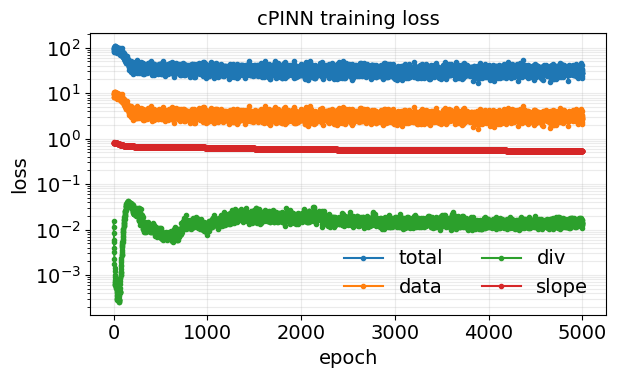

In [6]:
# PINN training-loss plot.
if not pinn_history.get("epoch"):
    print("No cPINN loss history found. Run the cPINN training cell first, with PyTorch available.")
else:
    epochs = np.asarray(pinn_history["epoch"], dtype=float)
    loss_keys = ["loss", "data", "div", "slope"]
    loss_labels = {
        "loss": "total",
        "data": "data",
        "div": "div",
        "slope": "slope",
    }
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, ax = plt.subplots(figsize=(6.4, 4.0))
        for key in loss_keys:
            vals = np.asarray(pinn_history.get(key, []), dtype=float)
            if vals.size == epochs.size and vals.size > 0:
                ax.semilogy(epochs, np.maximum(vals, 1.0e-30), marker="o", ms=3, lw=1.5, label=loss_labels[key])
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss")
        ax.set_title("cPINN training loss")
        ax.grid(True, which="both", alpha=0.25)
        ax.legend(frameon=False, ncol=2)
        fig.tight_layout()
        plt.show()


In [7]:
# Rectangular-grid face flux diagnostic only.  The Deng transport below uses the nodal dual mesh C_z.
n1 = face_neighbors[:, 0].astype(int)
n2 = face_neighbors[:, 1].astype(int)
is_internal_face = (n1 > 0) & (n2 > 0)
is_boundary_face = ~is_internal_face

owner_int = n1[is_internal_face] - 1
neigh_int = n2[is_internal_face] - 1
owner_b = np.maximum(n1[is_boundary_face], n2[is_boundary_face]) - 1
sgn_b = np.ones(np.count_nonzero(is_boundary_face), dtype=float)
sgn_b[n1[is_boundary_face] == 0] = -1.0

owner = np.concatenate([owner_int, owner_b]).astype(int)
neigh = np.concatenate([neigh_int, -np.ones_like(owner_b)]).astype(int)
has_neighbor = neigh >= 0
is_boundary_conn = ~has_neighbor
inlet_s = np.full(owner.shape, BOUNDARY_INFLOW_S, dtype=float)


def global_face_flux_to_fout(global_face_flux):
    global_face_flux = np.asarray(global_face_flux, dtype=float).reshape(-1)
    return np.concatenate([
        global_face_flux[is_internal_face],
        global_face_flux[is_boundary_face] * sgn_b,
    ]).astype(float)


def _face_quadrature(n_quad=2):
    if n_quad == 1:
        return np.array([0.5], dtype=float), np.array([1.0], dtype=float)
    xi, wi = np.polynomial.legendre.leggauss(n_quad)
    return 0.5 * (xi + 1.0), 0.5 * wi


def face_global_flux_from_cell_velocity(velocity_on_cell_fn, n_quad=2, average_internal=True):
    xi, wi = _face_quadrature(n_quad)
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    cell1 = face_neighbors[:, 0].astype(np.int64) - 1
    cell2 = face_neighbors[:, 1].astype(np.int64) - 1
    internal = (cell1 >= 0) & (cell2 >= 0)
    owner_cell = np.maximum(cell1, cell2)
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        vel = np.zeros_like(pts)
        if np.any(internal):
            q1v = velocity_on_cell_fn(pts[internal], cell1[internal])
            if average_internal:
                q2v = velocity_on_cell_fn(pts[internal], cell2[internal])
                vel[internal] = 0.5 * (q1v + q2v)
            else:
                vel[internal] = q1v
        if np.any(~internal):
            vel[~internal] = velocity_on_cell_fn(pts[~internal], owner_cell[~internal])
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux


def face_global_flux_from_velocity(velocity_fn, n_quad=2):
    xi, wi = _face_quadrature(n_quad)
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        vel = velocity_fn(pts)
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux

face_flux_cg_global = face_global_flux_from_cell_velocity(q_cg_on_rect_cell_numpy, n_quad=2, average_internal=True)
face_flux_nlr_global = face_global_flux_from_cell_velocity(q_nlr_on_rect_cell_numpy, n_quad=2, average_internal=True)
face_flux_cvfem_global = face_global_flux_from_cell_velocity(q_cvfem_on_rect_cell_numpy, n_quad=2, average_internal=True)
face_flux_pinn_global = None

Fout_CG = global_face_flux_to_fout(face_flux_cg_global)
Fout_NLR = global_face_flux_to_fout(face_flux_nlr_global)
Fout_CVFEM = global_face_flux_to_fout(face_flux_cvfem_global)
transport_fluxes = {"CG": Fout_CG, "NLR": Fout_NLR, "CVFEM": Fout_CVFEM}
face_flux_by_method = {"CG": face_flux_cg_global, "NLR": face_flux_nlr_global, "CVFEM": face_flux_cvfem_global}
if PINN_ACTIVE:
    face_flux_pinn_global = face_global_flux_from_velocity(q_rec_numpy, n_quad=2)
    Fout_PINN = global_face_flux_to_fout(face_flux_pinn_global)
    transport_fluxes["PINN"] = Fout_PINN
    face_flux_by_method["PINN"] = face_flux_pinn_global
else:
    print("cPINN rectangular-face diagnostic skipped.")
if MRST_REFERENCE_AVAILABLE:
    Fout_MRST = global_face_flux_to_fout(face_flux_mrst_export)
    transport_fluxes["MRST"] = Fout_MRST
    face_flux_by_method["MRST"] = face_flux_mrst_export


def cell_single_phase_residual(Fout):
    residual = np.zeros(ncell, dtype=float)
    np.add.at(residual, owner, Fout)
    np.add.at(residual, neigh[has_neighbor], -Fout[has_neighbor])
    return residual - source_rate_cell

print("Rectangular-cell diagnostic only (not the Deng transport CV): sum outward face flux minus cell source int_K f:")
for name, Fout in transport_fluxes.items():
    r = cell_single_phase_residual(Fout)
    print(f"  {name:<5} {residual_stats(r)}")
if MRST_REFERENCE_AVAILABLE:
    print("Face-flux comparison relative to matched MRST/TPFA:")
    for name, Fout in transport_fluxes.items():
        err = Fout - Fout_MRST
        print(f"  {name:<5} mean|F-F_FV|={np.mean(np.abs(err)):.3e}, rmse={np.sqrt(np.mean(err**2)):.3e}, max|F-F_FV|={np.max(np.abs(err)):.3e}")

print("Boundary single-phase flux audit, signed outward sums:")
_boundary_masks = {
    "left": is_boundary_face & np.isclose(face_centroid[:, 0], xmin, atol=1.0e-12),
    "right": is_boundary_face & np.isclose(face_centroid[:, 0], xmax, atol=1.0e-12),
    "bottom": is_boundary_face & np.isclose(face_centroid[:, 1], ymin, atol=1.0e-12),
    "top": is_boundary_face & np.isclose(face_centroid[:, 1], ymax, atol=1.0e-12),
}
for side, mask in _boundary_masks.items():
    row = [f"  {side:<6}"]
    for name, flux in face_flux_by_method.items():
        row.append(f"{name} sum={np.sum(flux[mask]):+.3e}")
    print("; ".join(row))


Rectangular-cell diagnostic only (not the Deng transport CV): sum outward face flux minus cell source int_K f:
  CG    n=4096 mean|R|=2.452376e-03 median|R|=9.988350e-06 rmse=6.140307e-02 max|R|=3.570737e+00 sum(R)=-2.961567e-04
  NLR   n=4096 mean|R|=2.402416e-03 median|R|=9.969260e-06 rmse=6.193129e-02 max|R|=3.612044e+00 sum(R)=-2.221169e-04
  CVFEM n=4096 mean|R|=2.398010e-03 median|R|=1.000313e-05 rmse=6.211681e-02 max|R|=3.623920e+00 sum(R)=-2.222904e-04
  PINN  n=4096 mean|R|=3.081396e-03 median|R|=2.004057e-06 rmse=7.311044e-02 max|R|=4.444871e+00 sum(R)=-8.800585e-02
Boundary single-phase flux audit, signed outward sums:
  left  ; CG sum=+5.007e-01; NLR sum=+5.007e-01; CVFEM sum=+5.005e-01; PINN sum=+5.527e-01
  right ; CG sum=-3.716e+00; NLR sum=-3.716e+00; CVFEM sum=-3.715e+00; PINN sum=-3.853e+00
  bottom; CG sum=-3.813e-01; NLR sum=-3.813e-01; CVFEM sum=-3.814e-01; PINN sum=-3.880e-01
  top   ; CG sum=-4.040e-01; NLR sum=-4.040e-01; CVFEM sum=-4.045e-01; PINN sum=-3.992e-0

Integrated MRST-dual face-flux error, int_e (v_w-v_FV).n ds:
  method        L2 error      relL2      mean|e|        RMSE       max|e|
  CG       2.039785e-01  4.680e-02   5.2258e-04  2.2021e-03  7.7700e-02
  PINN     2.318554e+00  5.319e-01   4.7842e-03  2.5031e-02  6.6814e-01
  NLR      1.634666e-01  3.750e-02   4.9120e-04  1.7648e-03  5.5597e-02
  CVFEM    1.558909e-01  3.577e-02   4.6990e-04  1.6830e-03  5.3183e-02


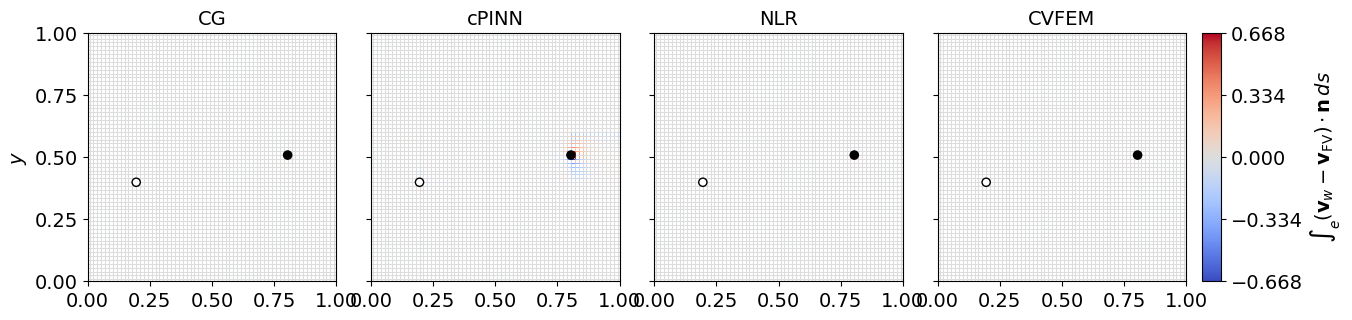

In [8]:
# MRST dual-face integrated flux comparison.
# Each error is int_e (v_w - v_FV) . n ds on the exported MRST dual face e.
from matplotlib.collections import LineCollection
from matplotlib.colors import TwoSlopeNorm

required_dual_face_keys = ["face_flux", "face_p1", "face_p2", "face_normal", "face_len", "face_centroid"]
if not MRST_FINE_AVAILABLE or any(key not in mrst_fine for key in required_dual_face_keys):
    dual_mrst_face_flux_by_method = {}
    dual_mrst_face_flux_error = {}
    dual_mrst_face_flux_error_l2 = {}
    print("MRST dual-face flux data are unavailable; skipping integrated face-flux comparison.")
else:
    mrst_dual_face_flux = np.asarray(mrst_fine["face_flux"], dtype=float).reshape(-1)
    mrst_dual_face_p1 = np.asarray(mrst_fine["face_p1"], dtype=float).reshape(-1, 2)
    mrst_dual_face_p2 = np.asarray(mrst_fine["face_p2"], dtype=float).reshape(-1, 2)
    mrst_dual_face_normal = np.asarray(mrst_fine["face_normal"], dtype=float).reshape(-1, 2)
    mrst_dual_face_len = np.asarray(mrst_fine["face_len"], dtype=float).reshape(-1)
    mrst_dual_face_centroid = np.asarray(mrst_fine["face_centroid"], dtype=float).reshape(-1, 2)

    def exported_dual_face_flux_from_velocity(velocity_fn, n_quad=3):
        xi, wi = _face_quadrature(n_quad)
        edge = mrst_dual_face_p2 - mrst_dual_face_p1
        flux = np.zeros(mrst_dual_face_flux.size, dtype=float)
        for s, w in zip(xi, wi):
            pts = mrst_dual_face_p1 + s * edge
            vel = velocity_fn(pts)
            flux += w * mrst_dual_face_len * np.einsum("ij,ij->i", vel, mrst_dual_face_normal)
        return flux

    dual_mrst_face_flux_by_method = {
        "CG": exported_dual_face_flux_from_velocity(q_cg_numpy, n_quad=3),
        "NLR": exported_dual_face_flux_from_velocity(q_nlr_numpy, n_quad=3),
        "CVFEM": exported_dual_face_flux_from_velocity(q_cvfem_numpy, n_quad=3),
    }
    if PINN_ACTIVE:
        dual_mrst_face_flux_by_method["PINN"] = exported_dual_face_flux_from_velocity(q_rec_numpy, n_quad=3)
    else:
        print("cPINN dual-face flux comparison skipped because PINN_ACTIVE is False.")

    dual_mrst_face_flux_error = {
        name: flux - mrst_dual_face_flux
        for name, flux in dual_mrst_face_flux_by_method.items()
    }
    dual_mrst_face_flux_error_l2 = {
        name: float(np.sqrt(np.sum(err ** 2)))
        for name, err in dual_mrst_face_flux_error.items()
    }
    _mrst_l2 = float(np.sqrt(np.sum(mrst_dual_face_flux ** 2)))

    print(r"Integrated MRST-dual face-flux error, int_e (v_w-v_FV).n ds:")
    print("  method        L2 error      relL2      mean|e|        RMSE       max|e|")
    for name in [m for m in ["CG", "PINN", "NLR", "CVFEM"] if m in dual_mrst_face_flux_error]:
        err = dual_mrst_face_flux_error[name]
        l2 = dual_mrst_face_flux_error_l2[name]
        rel = l2 / max(_mrst_l2, 1.0e-300)
        print(f"  {name:<6} {l2:14.6e} {rel:10.3e} {np.mean(np.abs(err)):12.4e} {np.sqrt(np.mean(err**2)):11.4e} {np.max(np.abs(err)):11.4e}")

    plot_order = [m for m in ["CG", "PINN", "NLR", "CVFEM"] if m in dual_mrst_face_flux_error]
    if plot_order:
        _vmax = max(float(np.nanmax(np.abs(dual_mrst_face_flux_error[m]))) for m in plot_order)
        _vmax = _vmax if np.isfinite(_vmax) and _vmax > 0.0 else 1.0e-14
        _norm = TwoSlopeNorm(vmin=-_vmax, vcenter=0.0, vmax=_vmax)
        _segments = np.stack([mrst_dual_face_p1, mrst_dual_face_p2], axis=1)
        with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
            fig, axes = plt.subplots(1, len(plot_order), figsize=(max(10.0, 3.25 * len(plot_order)), 4.5), squeeze=False)
            axes = axes[0]
            mappable = None
            for ax, name in zip(axes, plot_order):
                lc = LineCollection(_segments, cmap="coolwarm", norm=_norm, linewidths=0.75)
                lc.set_array(dual_mrst_face_flux_error[name])
                ax.add_collection(lc)
                mappable = lc
                ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
                ax.set_title("cPINN" if name == "PINN" else name)
                ax.set_aspect("equal")
                ax.set_xlim(xmin, xmax)
                ax.set_ylim(ymin, ymax)
                ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
                ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
                ax.grid(False)
            axes[0].set_ylabel(r"$y$")
            for ax in axes[1:]:
                ax.tick_params(labelleft=False)
            fig.subplots_adjust(left=0.055, right=0.90, bottom=0.08, top=0.90, wspace=0.14)
            fig.canvas.draw()
            pos = axes[-1].get_position()
            cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.015, pos.height])
            cbar = fig.colorbar(mappable, cax=cax)
            cbar.set_label(r"$\int_e (\mathbf{v}_w-\mathbf{v}_{\mathrm{FV}})\cdot\mathbf{n}\,ds$")
            cbar.set_ticks(np.linspace(-_vmax, _vmax, 5))
            plt.show()


In [9]:
# Explicit upwind Buckley-Leverett transport on the Deng nodal dual mesh C_z.
# This is the transport mesh for which the Deng/NLR reconstruction is locally conservative.
def fractional_flow_bl(S):
    S = np.asarray(S, dtype=float)
    return S ** 2 / (S ** 2 + (1.0 - S) ** 2 + 1.0e-30)


def segment_flux_velocity_fn(velocity_fn, a, bpt, n_out, n_quad=3):
    seg_len = edge_length(a, bpt)
    flux = 0.0
    for t, w in zip(_G3, _W3):
        x = a + t * (bpt - a)
        vel = velocity_fn(x[None, :])[0]
        flux += w * float(np.dot(vel, n_out)) * seg_len
    return float(flux)

# Dual control-volume storage and source terms.
dual_pv = np.zeros(n_nodes, dtype=float)
dual_source_rate = np.zeros(n_nodes, dtype=float)
for ci, cell in enumerate(rect["cells"]):
    for gi, vid in enumerate(cell["vids"]):
        dual_pv[int(vid)] += phi_matrix * cell_area[ci] / 4.0
        dual_source_rate[int(vid)] += source_rate_cell[ci] / 4.0

# Dual faces: inside each Q1 cell, four centroid-to-edge-midpoint segments
# connect neighboring nodal CVs; physical-boundary half edges connect to the exterior.
dual_owner = []
dual_neigh = []
dual_flux_by_method = {"CG": [], "NLR": [], "CVFEM": []}
if PINN_ACTIVE:
    dual_flux_by_method["PINN"] = []
_dual_pairs = [(0, 1), (1, 3), (3, 2), (2, 0)]
_dirichlet_tol = 1.0e-12
for ci, cell in enumerate(rect["cells"]):
    xy = cell["xy"]
    centroid = cell["centroid"]
    coeffs_cg = cell["uvals"]
    coeffs_nlr = local_fluxes[ci]["coeffs"]
    coeffs_cvfem = p_cvfem_nodes[cell["vids"]]

    for a_id, b_id in _dual_pairs:
        vi = xy[a_id]
        vj = xy[b_id]
        mid = 0.5 * (vi + vj)
        n_seg = normal_from_C_to_ti(centroid, mid, vi)
        dual_owner.append(int(cell["vids"][a_id]))
        dual_neigh.append(int(cell["vids"][b_id]))
        dual_flux_by_method["CG"].append(segment_flux(cell, coeffs_cg, centroid, mid, n_seg))
        dual_flux_by_method["NLR"].append(segment_flux(cell, coeffs_nlr, centroid, mid, n_seg))
        dual_flux_by_method["CVFEM"].append(segment_flux(cell, coeffs_cvfem, centroid, mid, n_seg))
        if PINN_ACTIVE:
            dual_flux_by_method["PINN"].append(segment_flux_velocity_fn(q_rec_numpy, centroid, mid, n_seg))

    # Physical boundary portions of boundary-node CVs.  Incoming boundary water is clean.
    for a_id, b_id in rect["edge_defs"]:
        a = xy[a_id]
        bpt = xy[b_id]
        is_phys_boundary = (
            (np.isclose(a[0], xmin, atol=_dirichlet_tol) and np.isclose(bpt[0], xmin, atol=_dirichlet_tol))
            or (np.isclose(a[0], xmax, atol=_dirichlet_tol) and np.isclose(bpt[0], xmax, atol=_dirichlet_tol))
            or (np.isclose(a[1], ymin, atol=_dirichlet_tol) and np.isclose(bpt[1], ymin, atol=_dirichlet_tol))
            or (np.isclose(a[1], ymax, atol=_dirichlet_tol) and np.isclose(bpt[1], ymax, atol=_dirichlet_tol))
        )
        if not is_phys_boundary:
            continue
        n_out = outward_edge_normal(a, bpt, centroid)
        mid = 0.5 * (a + bpt)
        for owner_vid, s0, s1 in ((int(cell["vids"][a_id]), a, mid), (int(cell["vids"][b_id]), mid, bpt)):
            dual_owner.append(owner_vid)
            dual_neigh.append(-1)
            dual_flux_by_method["CG"].append(segment_flux(cell, coeffs_cg, s0, s1, n_out))
            dual_flux_by_method["NLR"].append(segment_flux(cell, coeffs_nlr, s0, s1, n_out))
            dual_flux_by_method["CVFEM"].append(segment_flux(cell, coeffs_cvfem, s0, s1, n_out))
            if PINN_ACTIVE:
                dual_flux_by_method["PINN"].append(segment_flux_velocity_fn(q_rec_numpy, s0, s1, n_out))

dual_owner = np.asarray(dual_owner, dtype=np.int64)
dual_neigh = np.asarray(dual_neigh, dtype=np.int64)
dual_has_neighbor = dual_neigh >= 0
dual_is_boundary = ~dual_has_neighbor
dual_flux_by_method = {name: np.asarray(vals, dtype=float) for name, vals in dual_flux_by_method.items()}
if "MRST" in transport_fluxes:
    print("MRST transport is not included on the Deng nodal dual mesh; MRST lives on its own cell-centered grid.")


def dual_single_phase_residual(Fout):
    residual = np.zeros(n_nodes, dtype=float)
    np.add.at(residual, dual_owner, Fout)
    np.add.at(residual, dual_neigh[dual_has_neighbor], -Fout[dual_has_neighbor])
    return residual - dual_source_rate

print("Deng nodal-dual single-phase balance, sum outward dual-face flux minus source:")
for name, Fout in dual_flux_by_method.items():
    r = dual_single_phase_residual(Fout)
    print(f"  {name:<5} all={residual_stats(r)}")
    print(f"        interior={residual_stats(r, interior_vertex_ids)}")


def compute_dual_transport_dt(Fout):
    outflow = np.zeros(n_nodes, dtype=float)
    np.add.at(outflow, dual_owner, np.maximum(Fout, 0.0))
    np.add.at(outflow, dual_neigh[dual_has_neighbor], np.maximum(-Fout[dual_has_neighbor], 0.0))
    outflow += np.abs(dual_source_rate)
    active = (outflow > 1.0e-30) & (dual_pv > 0.0)
    if not np.any(active):
        raise RuntimeError("No dual-CV outflow/source terms found for the fixed flux field.")
    return CFL * np.min(dual_pv[active] / (FPRIME_MAX * outflow[active]))


def dual_source_water_rate(S):
    S = np.asarray(S, dtype=float)
    out = np.zeros_like(S)
    pos = dual_source_rate > 0.0
    neg = dual_source_rate < 0.0
    out[pos] = dual_source_rate[pos] * fractional_flow_bl(SOURCE_SATURATION)
    out[neg] = dual_source_rate[neg] * fractional_flow_bl(S[neg])
    return out


def advance_dual_transport(Fout, t_final, clip=True, nsteps_override=None):
    Fout = np.asarray(Fout, dtype=float)
    dt_cfl = compute_dual_transport_dt(Fout)
    if nsteps_override is None:
        if TRANSPORT_USE_FIXED_DT:
            nsteps = max(1, int(np.ceil(float(t_final) / TRANSPORT_DT)))
            dt_source = "fixed dt"
        else:
            nsteps = max(1, int(np.ceil(float(t_final) / dt_cfl)))
            dt_source = "method CFL"
    else:
        nsteps = max(1, int(nsteps_override))
        dt_source = "shared nsteps"
    dt = float(t_final) / nsteps
    dt_over_pv = np.zeros_like(dual_pv)
    active_pv = dual_pv > 0.0
    dt_over_pv[active_pv] = dt / dual_pv[active_pv]

    outward = Fout >= 0.0
    incoming_boundary = (~outward) & dual_is_boundary
    up_cv = np.empty_like(dual_owner)
    up_cv[outward] = dual_owner[outward]
    interior_negative = (~outward) & dual_has_neighbor
    up_cv[interior_negative] = dual_neigh[interior_negative]
    up_cv[incoming_boundary] = dual_owner[incoming_boundary]
    boundary_water_flux = fractional_flow_bl(BOUNDARY_INFLOW_S) * Fout

    S = np.zeros(n_nodes, dtype=float)
    cumulative_in = 0.0
    cumulative_out = 0.0
    cumulative_source = 0.0
    preclip_min = 0.0
    preclip_max = 0.0
    clipped_count = 0
    clip_mass_delta = 0.0

    for _ in range(nsteps):
        water_flux = fractional_flow_bl(S[up_cv]) * Fout
        water_flux[incoming_boundary] = boundary_water_flux[incoming_boundary]
        wb = water_flux[dual_is_boundary]
        cumulative_in += dt * float(np.sum(np.maximum(-wb, 0.0)))
        cumulative_out += dt * float(np.sum(np.maximum(wb, 0.0)))

        div = np.zeros(n_nodes, dtype=float)
        np.add.at(div, dual_owner, water_flux)
        np.add.at(div, dual_neigh[dual_has_neighbor], -water_flux[dual_has_neighbor])
        sw = dual_source_water_rate(S)
        cumulative_source += dt * float(np.sum(sw))
        S_new = S - dt_over_pv * (div - sw)
        preclip_min = min(preclip_min, float(np.min(S_new)))
        preclip_max = max(preclip_max, float(np.max(S_new)))
        if clip:
            S_clip = np.clip(S_new, 0.0, 1.0)
            clipped_count += int(np.count_nonzero(S_clip != S_new))
            clip_mass_delta += float(np.sum((S_clip - S_new) * dual_pv))
            S = S_clip
        else:
            S = S_new

    mass = float(np.sum(S * dual_pv))
    net = float(cumulative_in - cumulative_out + cumulative_source)
    denom = max(abs(cumulative_source) + cumulative_in, 1.0e-30)
    return S, {
        "T": float(t_final),
        "dt": float(dt),
        "dt_cfl": float(dt_cfl),
        "nsteps": int(nsteps),
        "dt_source": dt_source,
        "water_in": float(cumulative_in),
        "water_out": float(cumulative_out),
        "water_source": float(cumulative_source),
        "water_net": net,
        "water_mass": mass,
        "water_balance_error": float(mass - net),
        "water_balance_error_pct": float(100.0 * (mass - net) / denom),
        "preclip_min": float(preclip_min),
        "preclip_max": float(preclip_max),
        "clip_mass_delta": float(clip_mass_delta),
        "clipped_count": int(clipped_count),
        "pvi": float(t_final * source_rate_positive / PV_matrix),
    }

transport_cases = [(f"T{T:g}", float(T), float(T * source_rate_positive / PV_matrix)) for T in TRANSPORT_T_VALUES]
if TRANSPORT_CASE_KEY not in {key for key, _, _ in transport_cases}:
    TRANSPORT_CASE_KEY = transport_cases[0][0]

reference_dt = min(compute_dual_transport_dt(Fout) for Fout in dual_flux_by_method.values())
reference_nsteps = {key: max(1, int(np.ceil(T / (TRANSPORT_DT if TRANSPORT_USE_FIXED_DT else reference_dt)))) for key, T, _ in transport_cases}

transport_results = {}
for key, tfinal, pvi in transport_cases:
    transport_results[key] = {}
    nsteps_ref = reference_nsteps[key]
    for name, Fout in dual_flux_by_method.items():
        S, meta = advance_dual_transport(Fout, tfinal, clip=TRANSPORT_CLIP, nsteps_override=nsteps_ref)
        transport_results[key][name] = {"S": S, "meta": meta}

transport_rect_method_names = np.asarray(list(dual_flux_by_method.keys()), dtype=object)
transport_rect_saturation = {name: transport_results[TRANSPORT_CASE_KEY][name]["S"] for name in dual_flux_by_method}
transport_rect_meta = {name: transport_results[TRANSPORT_CASE_KEY][name]["meta"] for name in dual_flux_by_method}
transport_rect_S = np.vstack([transport_rect_saturation[name] for name in transport_rect_method_names])
transport_rect_water_mass = np.asarray([transport_rect_meta[name]["water_mass"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_net = np.asarray([transport_rect_meta[name]["water_net"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_balance_error = np.asarray([transport_rect_meta[name]["water_balance_error"] for name in transport_rect_method_names], dtype=float)
transport_rect_water_balance_error_pct = np.asarray([transport_rect_meta[name]["water_balance_error_pct"] for name in transport_rect_method_names], dtype=float)

print(f"Transport mesh: Deng nodal dual C_z, CVs={n_nodes}, faces={len(dual_owner)}")
print(f"Transport clipping enabled: {TRANSPORT_CLIP}")
print(f"Transport dt mode: {'fixed' if TRANSPORT_USE_FIXED_DT else 'CFL'}, requested dt={TRANSPORT_DT:.3e}, most restrictive CFL dt={reference_dt:.3e}")
print("Transport diagnostics:")
print("  case    method  nsteps        dt       CFL dt      PVI    min(S)    max(S)  preclip min  preclip max    clip dM    balance%")
for key, _, _ in transport_cases:
    for name in transport_rect_method_names:
        item = transport_results[key][str(name)]
        S = item["S"]
        meta = item["meta"]
        print(
            f"  {key:<7} {str(name):<5} {meta['nsteps']:7d} {meta['dt']:10.4e} {meta['dt_cfl']:10.4e} {meta['pvi']:8.4f} "
            f"{np.nanmin(S):8.3e} {np.nanmax(S):8.3e} {meta['preclip_min']:12.3e} {meta['preclip_max']:12.3e} "
            f"{meta['clip_mass_delta']:11.3e} {meta['water_balance_error_pct']:10.3e}"
        )


Deng nodal-dual single-phase balance, sum outward dual-face flux minus source:
  CG    all=n=4225 mean|R|=1.978118e-04 median|R|=2.402706e-06 rmse=2.277918e-03 max|R|=4.566685e-02 sum(R)=-2.961567e-04
        interior=n=3969 mean|R|=2.098682e-04 median|R|=2.337437e-06 rmse=2.350225e-03 max|R|=4.566685e-02 sum(R)=-7.403918e-05
  NLR   all=n=4225 mean|R|=6.610759e-07 median|R|=2.233456e-17 rmse=5.965099e-06 max|R|=1.545094e-04 sum(R)=-2.221169e-04
        interior=n=3969 mean|R|=9.979325e-17 median|R|=1.886512e-17 rmse=2.858130e-16 max|R|=4.232725e-15 sum(R)=+2.459791e-14
  CVFEM all=n=4225 mean|R|=6.653149e-07 median|R|=2.602085e-17 rmse=6.036903e-06 max|R|=1.571037e-04 sum(R)=-2.222904e-04
        interior=n=3969 mean|R|=1.125512e-16 median|R|=2.081668e-17 rmse=3.196734e-16 max|R|=5.079270e-15 sum(R)=-1.555957e-14
  PINN  all=n=4225 mean|R|=2.615006e-03 median|R|=1.791680e-06 rmse=3.568001e-02 max|R|=1.249987e+00 sum(R)=-5.868501e-02
        interior=n=3969 mean|R|=2.777338e-03 median|

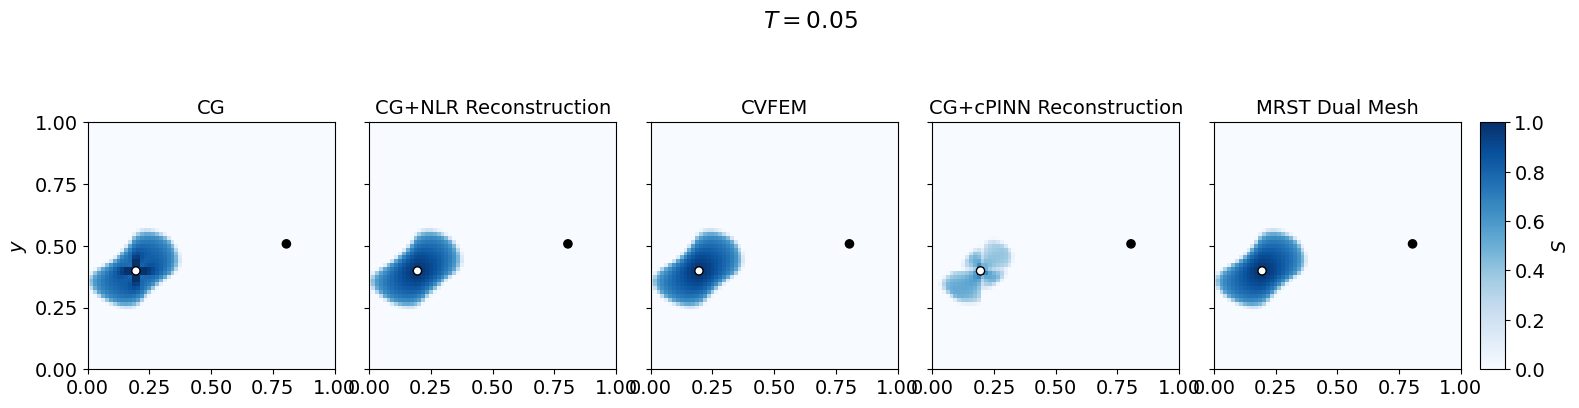

Saturation comparison case: T0.05, T=5.00000000e-02, PVI=0.050000
  MRST fine-pressure / dual-transport snapshot: sw_T005
  MRST dual-transport dt=3.52941176e-05, cumulative nsteps=1417
  method     mean|e|        RMSE       max|e|   vs MRST dual
  CG       1.5751e-03  1.0185e-02  1.6576e-01
  NLR      3.0327e-04  1.6254e-03  2.1163e-02
  CVFEM    1.9045e-04  1.0401e-03  1.5056e-02
  PINN     3.2137e-02  1.2591e-01  8.1043e-01


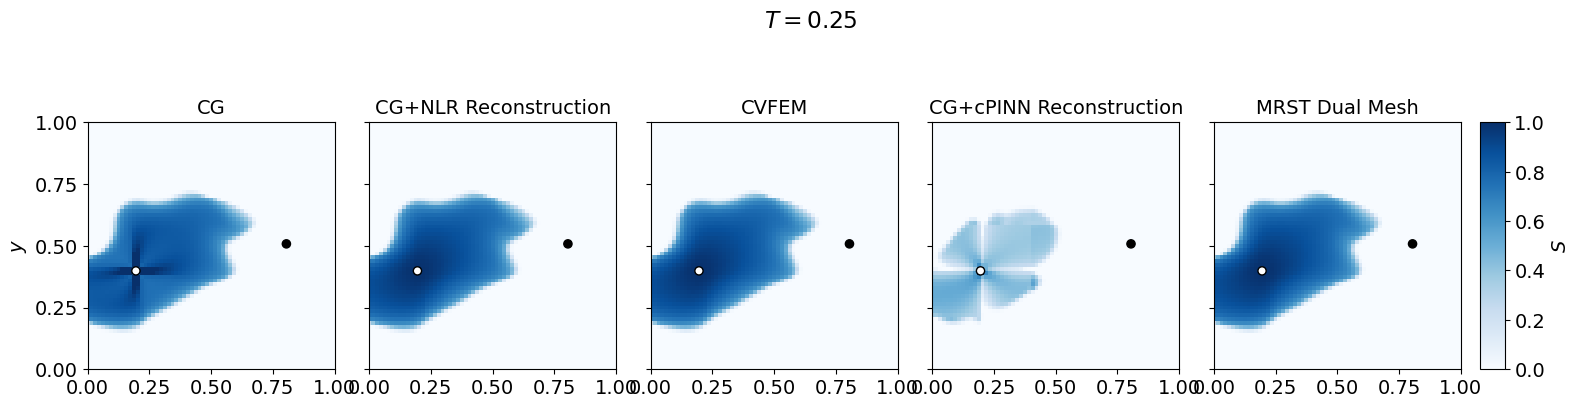

Saturation comparison case: T0.25, T=2.50000000e-01, PVI=0.250000
  MRST fine-pressure / dual-transport snapshot: sw_T025
  MRST dual-transport dt=3.53107345e-05, cumulative nsteps=7081
  method     mean|e|        RMSE       max|e|   vs MRST dual
  CG       7.2302e-03  2.5525e-02  2.1814e-01
  NLR      3.5769e-04  1.3657e-03  2.2958e-02
  CVFEM    2.6264e-04  1.1341e-03  1.9449e-02
  PINN     1.2754e-01  2.6711e-01  8.9895e-01


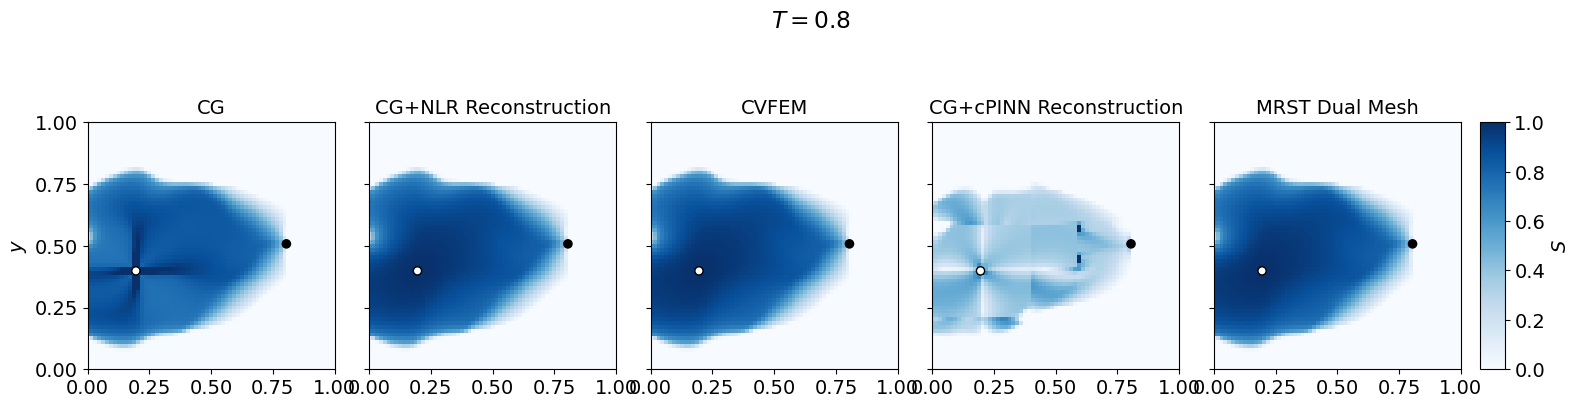

Saturation comparison case: T0.8, T=8.00000000e-01, PVI=0.800000
  MRST fine-pressure / dual-transport snapshot: sw_T080
  MRST dual-transport dt=3.53148911e-05, cumulative nsteps=22655
  method     mean|e|        RMSE       max|e|   vs MRST dual
  CG       1.9553e-02  4.6044e-02  2.3178e-01
  NLR      3.0322e-04  1.0994e-03  2.6303e-02
  CVFEM    2.9274e-04  1.0811e-03  2.7020e-02
  PINN     2.1582e-01  3.3907e-01  9.0778e-01
Selected case: T0.05, T=5.00000000e-02, PVI=0.050000
Global water mass balance on the Deng nodal dual mesh:
  method        stored water      boundary net       source term        total net    balance error       clip dM    error%       nsteps       dt
  CG         4.925647e-02    -4.696215e-06     5.000000e-02     4.999530e-02  -7.388361e-04 -7.388361e-04 -1.478e+00     1419 3.5236e-05
  NLR        4.999563e-02    -4.374503e-06     5.000000e-02     4.999563e-02   1.117162e-15  0.000000e+00  2.234e-12     1419 3.5236e-05
  CVFEM      4.999553e-02    -4.470104e-06

In [10]:
# Saturation plots and water-balance table on the Deng nodal dual mesh.
def dual_field_to_grid(field):
    return np.asarray(field, dtype=float).reshape((ny + 1, nx + 1))

x_dual_edges = np.concatenate([[xmin], 0.5 * (x_nodes[:-1] + x_nodes[1:]), [xmax]])
y_dual_edges = np.concatenate([[ymin], 0.5 * (y_nodes[:-1] + y_nodes[1:]), [ymax]])
case_lookup = {key: (tfinal, pvi) for key, tfinal, pvi in transport_cases}
selected_T, selected_PVI = case_lookup[TRANSPORT_CASE_KEY]
plot_methods = list(dual_flux_by_method.keys())
plot_titles = {"CG": "CG", "NLR": "CG+NLR Reconstruction", "CVFEM": "CVFEM", "PINN": "CG+cPINN Reconstruction"}

def snapshot_key_for_time(data, T, explicit=False):
    suffix = f"T{int(round(100.0 * float(T))):03d}"
    candidates = [f"sw_{suffix}_exp", f"sw_{suffix}"] if explicit else [f"sw_{suffix}", f"sw_{suffix}_exp"]
    for key in candidates:
        if key in data:
            arr = np.asarray(data[key]).reshape(-1)
            if arr.size:
                return key
    if "snap_times" in data:
        times = np.asarray(data["snap_times"], dtype=float).reshape(-1)
        if times.size:
            i = int(np.argmin(np.abs(times - float(T))))
            suffix = f"T{int(round(100.0 * float(times[i]))):03d}"
            candidates = [f"sw_{suffix}_exp", f"sw_{suffix}"] if explicit else [f"sw_{suffix}", f"sw_{suffix}_exp"]
            for key in candidates:
                if key in data:
                    arr = np.asarray(data[key]).reshape(-1)
                    if arr.size:
                        return key
    return None


MRST_PRIMAL_USE_EXPLICIT_TRANSPORT = True
MRST_DUAL_USE_EXPLICIT_TRANSPORT = True
_mrst_sw_key = snapshot_key_for_time(mrst, selected_T, explicit=MRST_PRIMAL_USE_EXPLICIT_TRANSPORT) if MRST_REFERENCE_AVAILABLE else None
_fine_sw_key = snapshot_key_for_time(mrst_fine, selected_T, explicit=MRST_DUAL_USE_EXPLICIT_TRANSPORT) if MRST_FINE_AVAILABLE else None


def dual_to_rect_cell_average(S_dual):
    V = np.asarray(S_dual, dtype=float).reshape((ny + 1, nx + 1))
    C = 0.25 * (V[:-1, :-1] + V[:-1, 1:] + V[1:, :-1] + V[1:, 1:])
    return C.reshape(-1)


def cell_field_to_grid_from_centroids(field, xc, nx_grid, ny_grid, phys=(1.0, 1.0)):
    field = np.asarray(field, dtype=float).reshape(-1)
    xc = np.asarray(xc, dtype=float).reshape(-1, 2)
    hx_grid = float(phys[0]) / int(nx_grid)
    hy_grid = float(phys[1]) / int(ny_grid)
    ix = np.rint((xc[:, 0] - 0.5 * hx_grid) / hx_grid).astype(int)
    iy = np.rint((xc[:, 1] - 0.5 * hy_grid) / hy_grid).astype(int)
    ix = np.clip(ix, 0, int(nx_grid) - 1)
    iy = np.clip(iy, 0, int(ny_grid) - 1)
    grid = np.full((int(ny_grid), int(nx_grid)), np.nan, dtype=float)
    grid[iy, ix] = field
    return grid


def fine_grid_info(data, S=None):
    if "xc_matrix" not in data:
        return None
    xc = np.asarray(data["xc_matrix"], dtype=float).reshape(-1, 2)
    size = int(np.asarray(S).size) if S is not None else int(xc.shape[0])
    if size == (nx + 1) * (ny + 1):
        return {
            "kind": "dual",
            "title": r"MRST fine-p dual mesh",
            "xc": xc,
            "nx": nx + 1,
            "ny": ny + 1,
            "x_edges": x_dual_edges,
            "y_edges": y_dual_edges,
        }
    n = int(round(np.sqrt(size)))
    return {
        "kind": "uniform",
        "title": r"MRST fine mesh",
        "xc": xc,
        "nx": n,
        "ny": n,
        "x_edges": np.linspace(0.0, physdim[0], n + 1),
        "y_edges": np.linspace(0.0, physdim[1], n + 1),
    }


def mrst_reference_grid(data, S):
    info = fine_grid_info(data, S)
    if info is None:
        raise ValueError("MRST reference export has no xc_matrix.")
    S = np.asarray(S, dtype=float).reshape(-1)
    if info["kind"] == "dual":
        grid = S.reshape((ny + 1, nx + 1))
    else:
        grid = cell_field_to_grid_from_centroids(S, info["xc"], info["nx"], info["ny"], phys=physdim)
    return info, grid


def build_dual_saturation_entries(case_key):
    case_T, case_PVI = case_lookup[case_key]
    entries = []
    for name in [m for m in ["CG", "NLR", "CVFEM", "PINN"] if m in plot_methods]:
        entries.append({
            "name": name,
            "title": plot_titles.get(name, name),
            "x_edges": x_dual_edges,
            "y_edges": y_dual_edges,
            "values": np.asarray(transport_results[case_key][name]["S"], dtype=float).reshape(-1),
            "grid": dual_field_to_grid(transport_results[case_key][name]["S"]),
        })
    fine_key = snapshot_key_for_time(mrst_fine, case_T, explicit=MRST_DUAL_USE_EXPLICIT_TRANSPORT) if MRST_FINE_AVAILABLE else None
    mrst_dual = None
    if fine_key is not None:
        mrst_dual = np.asarray(mrst_fine[fine_key], dtype=float).reshape(-1)
        if mrst_dual.size == (nx + 1) * (ny + 1):
            entries.append({
                "name": "MRST dual",
                "title": "MRST Dual Mesh",
                "x_edges": x_dual_edges,
                "y_edges": y_dual_edges,
                "values": mrst_dual,
                "grid": dual_field_to_grid(mrst_dual),
            })
        else:
            print(f"Skipping MRST dual panel at T={case_T:g}: expected {(nx+1)*(ny+1)} dual cells, got {mrst_dual.size}.")
            mrst_dual = None
    return entries, fine_key, mrst_dual


def plot_dual_saturation_comparison(case_key):
    case_T, case_PVI = case_lookup[case_key]
    entries, fine_key, mrst_dual = build_dual_saturation_entries(case_key)
    if not entries:
        print(f"No saturation entries found for {case_key}.")
        return entries, fine_key, mrst_dual

    fig_w = max(10.0, 3.25 * len(entries))
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(1, len(entries), figsize=(fig_w, 4.5), squeeze=False)
        axes = axes[0]
        pcm = None
        for ax, item in zip(axes, entries):
            pcm = ax.pcolormesh(item["x_edges"], item["y_edges"], item["grid"], cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
            ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
            ax.set_aspect("equal")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.set_title(item["title"])
            ax.grid(False)
        axes[0].set_ylabel(r"$y$")
        for ax in axes[1:]:
            ax.tick_params(labelleft=False)
        fig.suptitle(rf"$T={case_T:g}$", y=0.985)
        fig.subplots_adjust(left=0.055, right=0.90, bottom=0.08, top=0.84, wspace=0.14)
        fig.canvas.draw()
        pos = axes[-1].get_position()
        cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.015, pos.height])
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label(r"$S$")
        plt.show()

    print(f"Saturation comparison case: {case_key}, T={case_T:.8e}, PVI={case_PVI:.6f}")
    if fine_key is not None:
        print(f"  MRST fine-pressure / dual-transport snapshot: {fine_key}")
        if "meta_dt" in mrst_fine and "meta_nsteps" in mrst_fine:
            _times = np.asarray(mrst_fine.get("snap_times", []), dtype=float).reshape(-1)
            _idx = int(np.argmin(np.abs(_times - case_T))) if _times.size else 0
            _dt = np.asarray(mrst_fine["meta_dt"], dtype=float).reshape(-1)
            _ns = np.asarray(mrst_fine["meta_nsteps"]).reshape(-1)
            if _idx < _dt.size and _idx < _ns.size:
                print(f"  MRST dual-transport dt={_dt[_idx]:.8e}, cumulative nsteps={int(_ns[_idx])}")
    if mrst_dual is not None:
        print("  method     mean|e|        RMSE       max|e|   vs MRST dual")
        for item in entries:
            if item["name"] == "MRST dual":
                continue
            err = item["values"] - mrst_dual
            print(f"  {item['name']:<6} {np.mean(np.abs(err)):12.4e} {np.sqrt(np.mean(err**2)):11.4e} {np.max(np.abs(err)):11.4e}")
    return entries, fine_key, mrst_dual


TRANSPORT_COMPARISON_CASE_KEYS = ["T0.05", "T0.25", "T0.8"]
TRANSPORT_COMPARISON_CASE_KEYS = [key for key in TRANSPORT_COMPARISON_CASE_KEYS if key in case_lookup]
if TRANSPORT_CASE_KEY not in TRANSPORT_COMPARISON_CASE_KEYS:
    TRANSPORT_COMPARISON_CASE_KEYS.insert(0, TRANSPORT_CASE_KEY)

first_plot_entries = []
comparison_snapshot_keys = {}
for _case_key in TRANSPORT_COMPARISON_CASE_KEYS:
    _entries, _fine_key_case, _mrst_dual_case = plot_dual_saturation_comparison(_case_key)
    comparison_snapshot_keys[_case_key] = _fine_key_case
    if _case_key == TRANSPORT_CASE_KEY:
        first_plot_entries = _entries

# Keep the selected MRST snapshots for downstream T_h2 projections and saved diagnostics.
if _mrst_sw_key is not None:
    mrst_S_rect = _arr(_mrst_sw_key, float).reshape(-1)
else:
    mrst_S_rect = None
if _fine_sw_key is not None:
    fine_S = np.asarray(mrst_fine[_fine_sw_key], dtype=float).reshape(-1)
    fine_info, fine_grid = mrst_reference_grid(mrst_fine, fine_S)
    fine_xc = fine_info["xc"]
    fine_nx = fine_info["nx"]
    fine_ny = fine_info["ny"]
    fine_x_edges = fine_info["x_edges"]
    fine_y_edges = fine_info["y_edges"]
else:
    fine_S = None
    fine_info = None

print(f"Selected case: {TRANSPORT_CASE_KEY}, T={selected_T:.8e}, PVI={selected_PVI:.6f}")
print("Global water mass balance on the Deng nodal dual mesh:")
print("  method        stored water      boundary net       source term        total net    balance error       clip dM    error%       nsteps       dt")
for name in transport_rect_method_names:
    meta = transport_rect_meta[str(name)]
    boundary_net = meta["water_in"] - meta["water_out"]
    print(
        f"  {str(name):<6} {meta['water_mass']:16.6e} {boundary_net:16.6e} "
        f"{meta['water_source']:16.6e} {meta['water_net']:16.6e} "
        f"{meta['water_balance_error']:14.6e} {meta['clip_mass_delta']:13.6e} "
        f"{meta['water_balance_error_pct']:10.3e} "
        f"{meta['nsteps']:8d} {meta['dt']:10.4e}"
    )


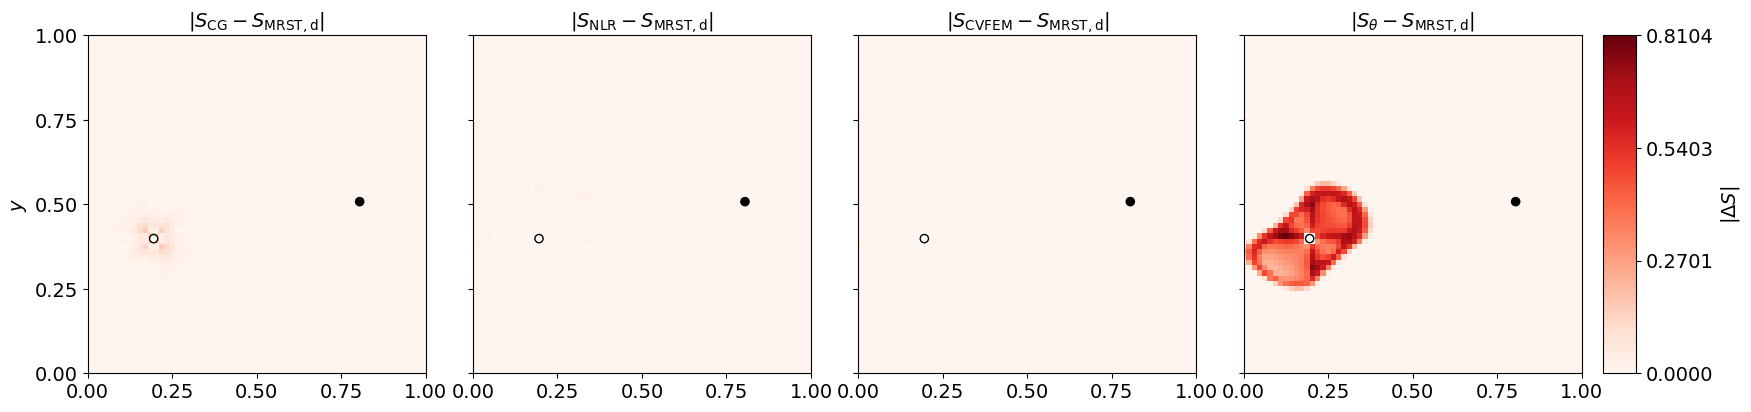

DG0 projection onto common $T_{h/2}$ grid (128 x 128):
  reference: MRST dual, snapshot=sw_T005
  method        L2 error       RMSE      max|e|
  CG       1.034391e-02 1.034391e-02 1.657556e-01
  NLR      1.641268e-03 1.641268e-03 2.116305e-02
  CVFEM    1.049884e-03 1.049884e-03 1.505598e-02
  PINN     1.278279e-01 1.278279e-01 8.104269e-01


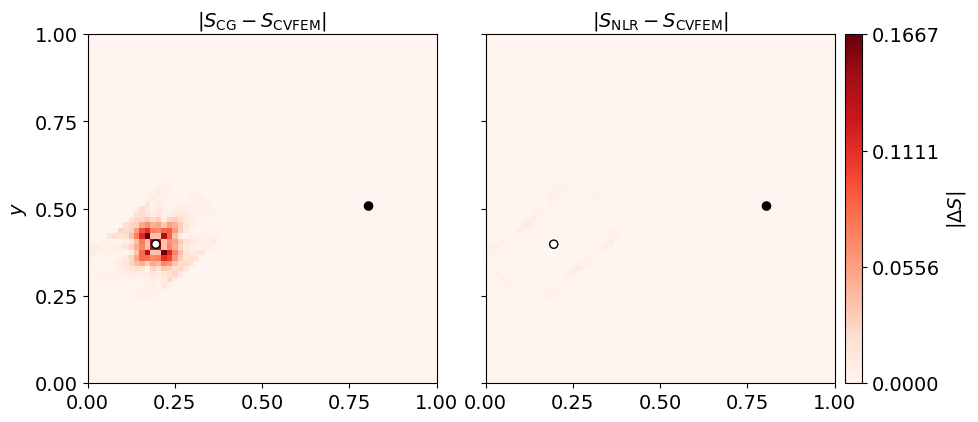

Saturation differences relative to CVFEM on common T_h2 grid:
  method        L2 error       RMSE      max|e|
  CG-CVFEM     1.048484e-02 1.048484e-02 1.666618e-01
  NLR-CVFEM    6.742085e-04 6.742085e-04 9.843033e-03


In [11]:
# Common DG0(T_{h/2}) projection for exact saturation-difference maps.
# T_{h/2} is the uniform 128x128 refinement of the primal 64x64 grid.  It
# exactly resolves both the primal MRST cells and the Deng nodal-dual CVs.
T_H2_NX = 2 * nx
T_H2_NY = 2 * ny
T_h2_x_edges = np.linspace(xmin, xmax, T_H2_NX + 1)
T_h2_y_edges = np.linspace(ymin, ymax, T_H2_NY + 1)
T_h2_x_centers = 0.5 * (T_h2_x_edges[:-1] + T_h2_x_edges[1:])
T_h2_y_centers = 0.5 * (T_h2_y_edges[:-1] + T_h2_y_edges[1:])
T_h2_cell_area = float(np.prod(physdim)) / float(T_H2_NX * T_H2_NY)


def project_dual_DG0_to_T_h2(S_dual):
    S_dual_grid = dual_field_to_grid(S_dual)
    ix_dual = np.searchsorted(x_dual_edges, T_h2_x_centers, side="right") - 1
    iy_dual = np.searchsorted(y_dual_edges, T_h2_y_centers, side="right") - 1
    ix_dual = np.clip(ix_dual, 0, nx)
    iy_dual = np.clip(iy_dual, 0, ny)
    return S_dual_grid[np.ix_(iy_dual, ix_dual)]


def project_primal_DG0_to_T_h2(S_primal):
    S_grid = cell_field_to_grid(S_primal)
    return np.repeat(np.repeat(S_grid, 2, axis=0), 2, axis=1)


def project_fine_DG0_to_T_h2(S_fine, fine_xc=None):
    S_fine = np.asarray(S_fine, dtype=float).reshape(-1)
    if S_fine.size == (nx + 1) * (ny + 1):
        return project_dual_DG0_to_T_h2(S_fine)
    if S_fine.size == T_H2_NX * T_H2_NY:
        if fine_xc is None:
            return S_fine.reshape((T_H2_NY, T_H2_NX))
        return cell_field_to_grid_from_centroids(S_fine, fine_xc, T_H2_NX, T_H2_NY, phys=physdim)
    raise ValueError(
        f"Expected either {(nx+1)*(ny+1)} dual cells or {T_H2_NX*T_H2_NY} fine cells, got {S_fine.size}."
    )

T_h2_fields = {}
for _name in plot_methods:
    T_h2_fields[_name] = project_dual_DG0_to_T_h2(transport_results[TRANSPORT_CASE_KEY][_name]["S"])
if _mrst_sw_key is not None:
    T_h2_fields["MRST primal"] = project_primal_DG0_to_T_h2(mrst_S_rect)
if _fine_sw_key is not None:
    T_h2_fields["MRST dual"] = project_fine_DG0_to_T_h2(fine_S, fine_xc if 'fine_xc' in globals() else None)

# Use the newest MRST dual-transport reference as S_MRST when available.
T_H2_ERROR_REFERENCE = "MRST dual" if "MRST dual" in T_h2_fields else "MRST primal"
T_H2_REFERENCE_SNAPSHOT = _fine_sw_key if T_H2_ERROR_REFERENCE == "MRST dual" else _mrst_sw_key
T_H2_ERROR_METHODS = [m for m in ["CG", "NLR", "CVFEM", "PINN"] if m in T_h2_fields]
T_H2_LABELS = {
    "CG": r"\mathrm{CG}",
    "NLR": r"\mathrm{NLR}",
    "CVFEM": r"\mathrm{CVFEM}",
    "PINN": r"\theta",
    "MRST primal": r"\mathrm{MRST,p}",
    "MRST dual": r"\mathrm{MRST,d}",
}
T_h2_abs_errors = {}
T_h2_l2_errors = {}
T_h2_rmse_errors = {}
if T_H2_ERROR_REFERENCE in T_h2_fields:
    ref_h2 = T_h2_fields[T_H2_ERROR_REFERENCE]
    for _name in T_H2_ERROR_METHODS:
        err = np.abs(T_h2_fields[_name] - ref_h2)
        T_h2_abs_errors[_name] = err
        T_h2_l2_errors[_name] = float(np.sqrt(np.nansum(err ** 2) * T_h2_cell_area))
        T_h2_rmse_errors[_name] = float(np.sqrt(np.nanmean(err ** 2)))

    _err_vmax = max(float(np.nanmax(v)) for v in T_h2_abs_errors.values()) if T_h2_abs_errors else 1.0
    _err_vmax = _err_vmax if np.isfinite(_err_vmax) and _err_vmax > 0.0 else 1.0e-12
    _ref_label = T_H2_LABELS.get(T_H2_ERROR_REFERENCE, r"\mathrm{MRST}")
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(1, len(T_h2_abs_errors), figsize=(4.5 * max(1, len(T_h2_abs_errors)), 4.5), squeeze=False)
        axes = axes[0]
        pcm = None
        for ax, (_name, _err) in zip(axes, T_h2_abs_errors.items()):
            pcm = ax.pcolormesh(T_h2_x_edges, T_h2_y_edges, _err, cmap="Reds", vmin=0.0, vmax=_err_vmax, shading="flat")
            ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
            _lab = T_H2_LABELS.get(_name, rf"\mathrm{{{_name}}}")
            ax.set_title(rf"$|S_{{{_lab}}}-S_{{{_ref_label}}}|$")
            ax.set_aspect("equal")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.grid(False)
        axes[0].set_ylabel(r"$y$")
        for ax in axes[1:]:
            ax.tick_params(labelleft=False)
        fig.subplots_adjust(left=0.07, right=0.90, bottom=0.08, top=0.92, wspace=0.14)
        fig.canvas.draw()
        pos = axes[-1].get_position()
        cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.018, pos.height])
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label(r"$|\Delta S|$")
        cbar.set_ticks(np.linspace(0.0, _err_vmax, 4))
        plt.show()

    print(r"DG0 projection onto common $T_{h/2}$ grid (128 x 128):")
    print(f"  reference: {T_H2_ERROR_REFERENCE}, snapshot={T_H2_REFERENCE_SNAPSHOT}")
    print("  method        L2 error       RMSE      max|e|")
    for _name, _err in T_h2_abs_errors.items():
        print(f"  {_name:<8} {T_h2_l2_errors[_name]:12.6e} {T_h2_rmse_errors[_name]:10.6e} {np.nanmax(_err):10.6e}")
    if "MRST primal" in T_h2_fields and "MRST dual" in T_h2_fields:
        _mrst_cross = np.abs(T_h2_fields["MRST primal"] - T_h2_fields["MRST dual"])
        _mrst_cross_l2 = float(np.sqrt(np.nansum(_mrst_cross ** 2) * T_h2_cell_area))
        _mrst_cross_rmse = float(np.sqrt(np.nanmean(_mrst_cross ** 2)))
        print(f"  MRST primal vs fine-p dual on T_h2: L2={_mrst_cross_l2:.6e}, RMSE={_mrst_cross_rmse:.6e}, max|e|={np.nanmax(_mrst_cross):.6e}")
else:
    T_h2_abs_errors = {}
    T_h2_l2_errors = {}
    T_h2_rmse_errors = {}
    print("Skipping T_h2 difference map: MRST reference is unavailable.")

# Direct method-to-CVFEM saturation differences on the same common grid.
T_h2_cvfem_abs_errors = {}
T_h2_cvfem_l2_errors = {}
T_h2_cvfem_rmse_errors = {}
if "CVFEM" in T_h2_fields:
    for _name in [m for m in ["CG", "NLR"] if m in T_h2_fields]:
        err = np.abs(T_h2_fields[_name] - T_h2_fields["CVFEM"])
        T_h2_cvfem_abs_errors[_name] = err
        T_h2_cvfem_l2_errors[_name] = float(np.sqrt(np.nansum(err ** 2) * T_h2_cell_area))
        T_h2_cvfem_rmse_errors[_name] = float(np.sqrt(np.nanmean(err ** 2)))

if T_h2_cvfem_abs_errors:
    _cv_vmax = max(float(np.nanmax(v)) for v in T_h2_cvfem_abs_errors.values())
    _cv_vmax = _cv_vmax if np.isfinite(_cv_vmax) and _cv_vmax > 0.0 else 1.0e-12
    with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
        fig, axes = plt.subplots(1, len(T_h2_cvfem_abs_errors), figsize=(4.5 * max(1, len(T_h2_cvfem_abs_errors)), 4.5), squeeze=False)
        axes = axes[0]
        pcm = None
        for ax, (_name, _err) in zip(axes, T_h2_cvfem_abs_errors.items()):
            pcm = ax.pcolormesh(T_h2_x_edges, T_h2_y_edges, _err, cmap="Reds", vmin=0.0, vmax=_cv_vmax, shading="flat")
            ax.scatter(source_points_effective[:, 0], source_points_effective[:, 1], c=["white", "black"], s=35, edgecolors="k", zorder=5)
            _lab = T_H2_LABELS.get(_name, rf"\mathrm{{{_name}}}")
            ax.set_title(rf"$|S_{{{_lab}}}-S_{{\mathrm{{CVFEM}}}}|$")
            ax.set_aspect("equal")
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
            ax.grid(False)
        axes[0].set_ylabel(r"$y$")
        for ax in axes[1:]:
            ax.tick_params(labelleft=False)
        fig.subplots_adjust(left=0.07, right=0.90, bottom=0.08, top=0.92, wspace=0.14)
        fig.canvas.draw()
        pos = axes[-1].get_position()
        cax = fig.add_axes([pos.x1 + 0.012, pos.y0, 0.018, pos.height])
        cbar = fig.colorbar(pcm, cax=cax)
        cbar.set_label(r"$|\Delta S|$")
        cbar.set_ticks(np.linspace(0.0, _cv_vmax, 4))
        plt.show()

    print("Saturation differences relative to CVFEM on common T_h2 grid:")
    print("  method        L2 error       RMSE      max|e|")
    for _name, _err in T_h2_cvfem_abs_errors.items():
        print(f"  {_name + '-CVFEM':<12} {T_h2_cvfem_l2_errors[_name]:12.6e} {T_h2_cvfem_rmse_errors[_name]:10.6e} {np.nanmax(_err):10.6e}")


In [12]:
# Save compact diagnostics for paper tables/figures.
OUT_DIR = pathlib.Path("result_deng_example4_blocks5_Q1_no_fracture")
OUT_DIR.mkdir(exist_ok=True)
np.savez(
    OUT_DIR / "diagnostics.npz",
    nx=np.array(nx),
    ny=np.array(ny),
    physdim=physdim,
    xc_matrix=xc_matrix,
    kappa_cell=kappa_cell_dg0,
    source_points_requested=SOURCE_POINTS_REQUESTED,
    source_points_effective=source_points_effective,
    source_cell_ids=source_cell_ids,
    source_rates=SOURCE_RATES,
    source_rate_cell=source_rate_cell,
    p_nodes=p_nodes,
    p_matrix_cg=p_matrix_cg,
    p_nlr_nodes=p_nlr_nodes,
    p_cvfem_nodes=p_cvfem_nodes,
    p_matrix_cvfem=p_matrix_cvfem,
    R_tau_cg=R_tau_cg,
    R_tau_nlr=R_tau_nlr,
    R_xi_cg=R_xi_cg,
    R_xi_nlr=R_xi_nlr,
    R_tau_cvfem=R_tau_cvfem,
    R_xi_cvfem=R_xi_cvfem,
    face_flux_cg=face_flux_cg_global,
    face_flux_nlr=face_flux_nlr_global,
    face_flux_cvfem=face_flux_cvfem_global,
    face_flux_pinn=np.asarray([]) if face_flux_pinn_global is None else face_flux_pinn_global,
    pinn_active=np.array(PINN_ACTIVE),
    pinn_history_epoch=np.asarray(pinn_history.get("epoch", []), dtype=float) if "pinn_history" in globals() else np.array([]),
    pinn_history_loss=np.asarray(pinn_history.get("loss", []), dtype=float) if "pinn_history" in globals() else np.array([]),
    pinn_history_data=np.asarray(pinn_history.get("data", []), dtype=float) if "pinn_history" in globals() else np.array([]),
    pinn_history_div=np.asarray(pinn_history.get("div", []), dtype=float) if "pinn_history" in globals() else np.array([]),
    dual_mrst_face_flux_error_methods=np.asarray(list(dual_mrst_face_flux_error_l2.keys()), dtype=object) if "dual_mrst_face_flux_error_l2" in globals() else np.asarray([], dtype=object),
    dual_mrst_face_flux_error_l2=np.asarray(list(dual_mrst_face_flux_error_l2.values()), dtype=float) if "dual_mrst_face_flux_error_l2" in globals() else np.asarray([], dtype=float),
    transport_method_names=transport_rect_method_names,
    transport_S=transport_rect_S,
    transport_T=np.array(selected_T),
    transport_PVI=np.array(selected_PVI),
    transport_water_mass=transport_rect_water_mass,
    transport_water_net=transport_rect_water_net,
    transport_water_balance_error=transport_rect_water_balance_error,
    transport_water_balance_error_pct=transport_rect_water_balance_error_pct,
    mrst_primal_snapshot_key=np.array(_mrst_sw_key if _mrst_sw_key is not None else ""),
    mrst_primal_use_explicit_transport=np.array(MRST_PRIMAL_USE_EXPLICIT_TRANSPORT if "MRST_PRIMAL_USE_EXPLICIT_TRANSPORT" in globals() else False),
    mrst_fine_snapshot_key=np.array(_fine_sw_key if _fine_sw_key is not None else ""),
    mrst_dual_use_explicit_transport=np.array(MRST_DUAL_USE_EXPLICIT_TRANSPORT if "MRST_DUAL_USE_EXPLICIT_TRANSPORT" in globals() else False),
    mrst_fine_file=np.array(str(FINE_MRST_FILE) if FINE_MRST_FILE is not None else ""),
    mrst_fine_meta_grid=np.array(str(mrst_fine.get("meta_grid", "")) if MRST_FINE_AVAILABLE else ""),
    mrst_fine_meta_workflow=np.array(str(mrst_fine.get("meta_workflow", "")) if MRST_FINE_AVAILABLE else ""),
    mrst_fine_dt=np.asarray(mrst_fine.get("meta_dt", []), dtype=float) if MRST_FINE_AVAILABLE else np.array([]),
    mrst_fine_nsteps=np.asarray(mrst_fine.get("meta_nsteps", [])) if MRST_FINE_AVAILABLE else np.array([]),
    T_h2_l2_error_methods=np.asarray(list(T_h2_l2_errors.keys()), dtype=object) if "T_h2_l2_errors" in globals() else np.asarray([], dtype=object),
    T_h2_l2_errors=np.asarray(list(T_h2_l2_errors.values()), dtype=float) if "T_h2_l2_errors" in globals() else np.asarray([], dtype=float),
    T_h2_rmse_errors=np.asarray([T_h2_rmse_errors[k] for k in T_h2_l2_errors.keys()], dtype=float) if "T_h2_l2_errors" in globals() and "T_h2_rmse_errors" in globals() else np.asarray([], dtype=float),
    T_h2_reference=np.array(T_H2_ERROR_REFERENCE if "T_H2_ERROR_REFERENCE" in globals() else ""),
    T_h2_cvfem_l2_error_methods=np.asarray(list(T_h2_cvfem_l2_errors.keys()), dtype=object) if "T_h2_cvfem_l2_errors" in globals() else np.asarray([], dtype=object),
    T_h2_cvfem_l2_errors=np.asarray(list(T_h2_cvfem_l2_errors.values()), dtype=float) if "T_h2_cvfem_l2_errors" in globals() else np.asarray([], dtype=float),
    T_h2_cvfem_rmse_errors=np.asarray([T_h2_cvfem_rmse_errors[k] for k in T_h2_cvfem_l2_errors.keys()], dtype=float) if "T_h2_cvfem_l2_errors" in globals() and "T_h2_cvfem_rmse_errors" in globals() else np.asarray([], dtype=float),
)
print(f"Saved diagnostics to {OUT_DIR / 'diagnostics.npz'}")


Saved diagnostics to result_deng_example4_blocks5_Q1_no_fracture/diagnostics.npz
